# 01 — Plane atlas: what the candidate ABCD planes look like

Inputs: the `abcd_scan` campaign (see `README.md` for selection, normalization, and the
pre-registered decision rule). This notebook establishes the ingredients every later
verdict rests on: correct normalization, the isolation-quirk rates, what each candidate
plane looks like per background process, and the displacement-convention cross-check.

**All plane inspections here use the even-parity half only** — the odd half is reserved
for the notebook-04 confirmation.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

import plot_helpers as ph

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (9, 7)
# even-parity half of the sample = half the effective luminosity
LUMI_LABEL = ph.LUMI_EVEN
cms_label = ph.cms_label

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.ANALYSIS_BACKGROUNDS)} background samples "
      f"(DYJetsToMuMu_M50 excluded); scan hists: {len(total_bkg)}")

accumulated 17 background samples (DYJetsToMuMu_M50 excluded); scan hists: 8


## Normalization table

Per sample: the campaign's processed sum of weights, the census pre-skim/pre-filter
denominator, the processed-fraction correction, and the resulting offline factor.
How to read it: `factor` multiplies the merged hists; a factor far from the yaml
skim_factor signals a normalization assumption that would have been wrong.

In [2]:
rows = []
for s in sorted(ss.BACKGROUNDS) + ss.SIGNALS_2MU2E + ss.SIGNALS_4MU:
    o = ss.fetch(s)
    ssw = o["metadata"]["scaled_sum_weights"]
    fw = ss.FW.get(s, 1.0)
    rows.append((s, ss.BACKGROUNDS.get(s, "signal"), ssw, SUMW_PRE[s], fw,
                 ssw / SUMW_PRE[s] / fw))
print(f"{'sample':34s} {'process':8s} {'sumw_proc':>12s} {'sumw_pre':>14s} {'f_w':>8s} {'factor':>10s}")
for r in rows:
    print(f"{r[0]:34s} {r[1]:8s} {r[2]:12.4g} {r[3]:14.4g} {r[4]:8.4f} {r[5]:10.4g}")

sample                             process     sumw_proc       sumw_pre      f_w     factor
DYJetsToMuMu_M10to50               DY          1.143e+09      6.791e+10   1.0000    0.01683
DYJetsToMuMu_M50                   DY          1.454e+14      2.199e+20   1.0000   6.61e-07
QCD_Pt1000                         QCD         1.529e+07      2.653e+07   0.9997     0.5768
QCD_Pt120To170                     QCD         6.052e+05      3.896e+07   1.0000    0.01553
QCD_Pt15To20                       QCD               845      9.344e+06   1.0000  9.044e-05
QCD_Pt170To300                     QCD         3.796e+06      5.696e+07   1.0000    0.06664
QCD_Pt20To30                       QCD         2.295e+04      6.109e+07   1.0000  0.0003758
QCD_Pt300To470                     QCD             7e+06      5.636e+07   1.0000     0.1242
QCD_Pt30To50                       QCD         1.079e+05      5.766e+07   1.0000   0.001871
QCD_Pt470To600                     QCD         8.042e+06      3.816e+07   1.0000

### The excluded DY M50 sample, bounded by counts

DYJetsToMuMu_M50 is excluded from all weighted results (rogue generator weights
contaminate its skimmed events — see README). Its possible contribution is bounded
here using raw event counts normalized with lumi x cross section over the
approximate pre-skim event count: an order-of-magnitude upper estimate, compared
against the total background at preselection.

In [3]:
# Count-based bound (weights unusable): raw presel skim events, normalized with
# lumi * xs / N_pre where N_pre approximates the pre-skim event count from the
# skim size and the documented skim fraction. An order-of-magnitude UPPER estimate.
LUMI_PB = 59830.0       # 2018, pb^-1
XS_M50_PB = 1976.0      # repo cross_sections.yaml value for DYJetsToMuMu_M50
N_SKIM_EVENTS = 3.16e6  # events in the 2018_v2 skims (census)
SKIM_FRACTION = 0.0132  # documented skim fraction -> N_pre ~ N_SKIM/SKIM_FRACTION
n_pre = N_SKIM_EVENTS / SKIM_FRACTION
for ch in ss.CHANNELS:
    hname = "abcd_scan_2mu2e_iso_iso" if ch == "2mu2e" else "abcd_scan_4mu_iso_iso"
    raw_evts = ss.fetch("DYJetsToMuMu_M50")["cutflow"][ss.CHANNELS[ch]]
    rows = list(raw_evts.rows.values())
    n_raw = rows[-1]["raw"] if rows else 0
    bound = LUMI_PB * XS_M50_PB * n_raw / max(n_pre, 1)
    tot = total_bkg[hname][{"channel": ss.CHANNELS[ch]}].sum(flow=True).value
    print(f"{ch}: DY-M50 presel raw events = {n_raw}; count-based yield bound ~ {bound:.3g} "
          f"vs total bkg {tot:.4g} ({bound/max(tot,1e-9):.1%})")

2mu2e: DY-M50 presel raw events = 706; count-based yield bound ~ 349 vs total bkg 7.493e+04 (0.5%)


4mu: DY-M50 presel raw events = 764; count-based yield bound ~ 377 vs total bkg 2.375e+04 (1.6%)


## Cross sections

Values baked into the campaign (from `sidm/configs/cross_sections.yaml`, sourced from
XSDB; diboson from GenXSecAnalyzer). TTJets is kept at the repo's 471.7 pb; the
NNLO+NNLL value (831.76 pb) is a pending explicit sign-off — the cell shows how much
the *total* background composition would move (TTJets is subdominant to QCD, so the
plane verdicts are insensitive to this choice; it matters for absolute yields).

In [4]:
print(f"TTJets rescale if NNLO adopted: x{at.ttjets_xsec_rescale():.3f}")
for ch in ss.CHANNELS:
    h = "abcd_scan_2mu2e_iso_iso" if ch == "2mu2e" else "abcd_scan_4mu_iso_iso"
    tot = total_bkg[h][{"channel": ss.CHANNELS[ch]}].sum(flow=True).value
    tt = by_process["TTJets"][h][{"channel": ss.CHANNELS[ch]}].sum(flow=True).value
    print(f"{ch}: TTJets fraction of total bkg (presel) = {tt/tot:.3f}"
          f" -> with NNLO: {tt*at.ttjets_xsec_rescale()/(tot+tt*(at.ttjets_xsec_rescale()-1)):.3f}")

TTJets rescale if NNLO adopted: x1.763
2mu2e: TTJets fraction of total bkg (presel) = 0.047 -> with NNLO: 0.080


4mu: TTJets fraction of total bkg (presel) = 0.012 -> with NNLO: 0.021


## Isolation-quirk rates

Fraction of events whose leading LJ has no matched AK4 jet (the sentinel bin — the
processor would have silently called these "perfectly isolated"). How to read it: a
large sentinel fraction in a background process means prescription (i) puts
unconstrainable events into the plane; the decision rule discards prescription (i)
for a plane if sentinel events exceed ~20% of its A region.

In [5]:
import gc
quirk = {}
for ch, hname, axes in [("2mu2e", "abcd_scan_2mu2e_iso_iso", ["muiso", "egmiso"]),
                        ("4mu", "abcd_scan_4mu_iso_iso", ["muiso0", "muiso1"])]:
    print(f"--- {ch}")
    sigs = ss.SIGNALS_2MU2E if ch == "2mu2e" else ss.SIGNALS_4MU

    def _rates(label, hists):
        h = at.get_channel(hists[hname], ss.CHANNELS[ch])
        parts = []
        for axn in axes:
            col = at.project_plane(h, axn, "parity", {})[0][:, 0]   # even half
            tot = col.sum()
            rate = col[0] / tot if tot > 0 else np.nan
            quirk[f"{ch}/{label}/{axn}"] = rate
            parts.append(f"{axn}: {rate:.4f}" if np.isfinite(rate) else f"{axn}: n/a")
        print(f"  {label:28s} " + "  ".join(parts))

    _rates("total bkg", total_bkg)
    for p in ss.PROCESSES:
        _rates(p, by_process[p])
    for s in sigs:                       # one signal in memory at a time
        hs = load_sig(s)
        _rates(s, hs)
        del hs
        gc.collect()

--- 2mu2e


  total bkg                    muiso: 0.0009  egmiso: 0.0011


  QCD                          muiso: 0.0010  egmiso: 0.0012


  DY                           muiso: 0.0000  egmiso: 0.0000


  TTJets                       muiso: 0.0000  egmiso: 0.0000


...

  4Mu_1000GeV_1p2GeV_9p6mm     muiso0: 0.1143  muiso1: 0.1358


  4Mu_500GeV_0p25GeV_0p4mm     muiso0: 0.0312  muiso1: 0.0385


  4Mu_500GeV_0p25GeV_4p0mm     muiso0: 0.1755  muiso1: 0.1864


  4Mu_500GeV_5p0GeV_8p0mm      muiso0: 0.0290  muiso1: 0.0374


  4Mu_500GeV_5p0GeV_80p0mm     muiso0: 0.2469  muiso1: 0.2651


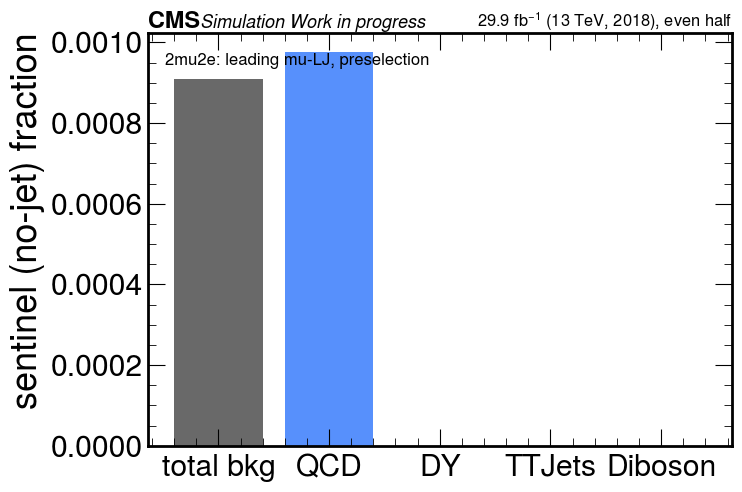

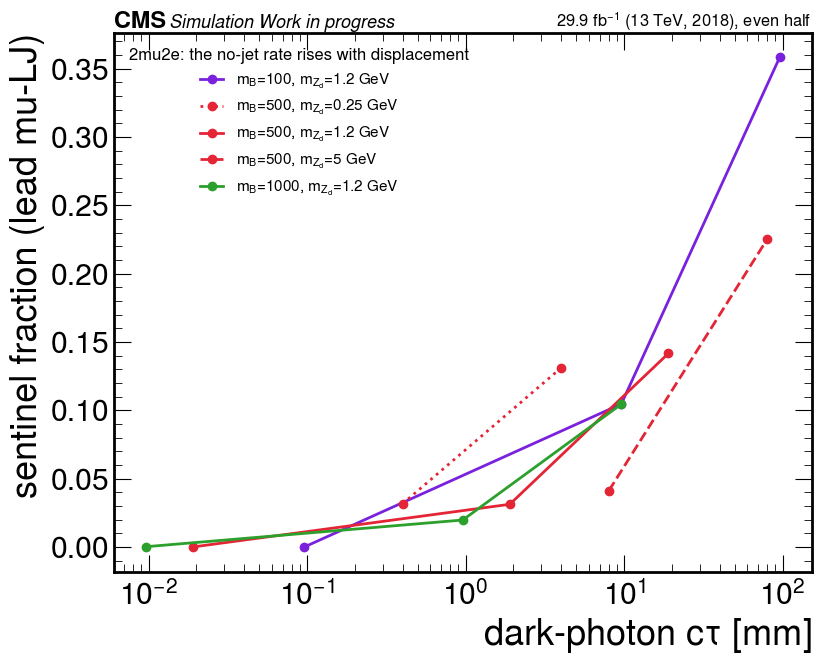

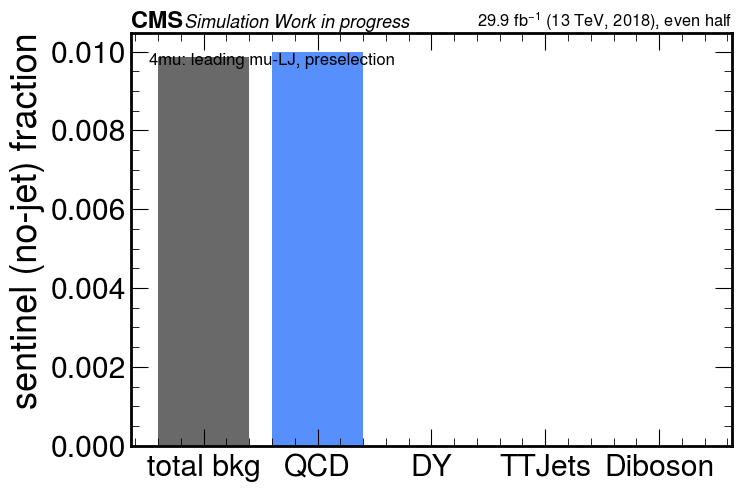

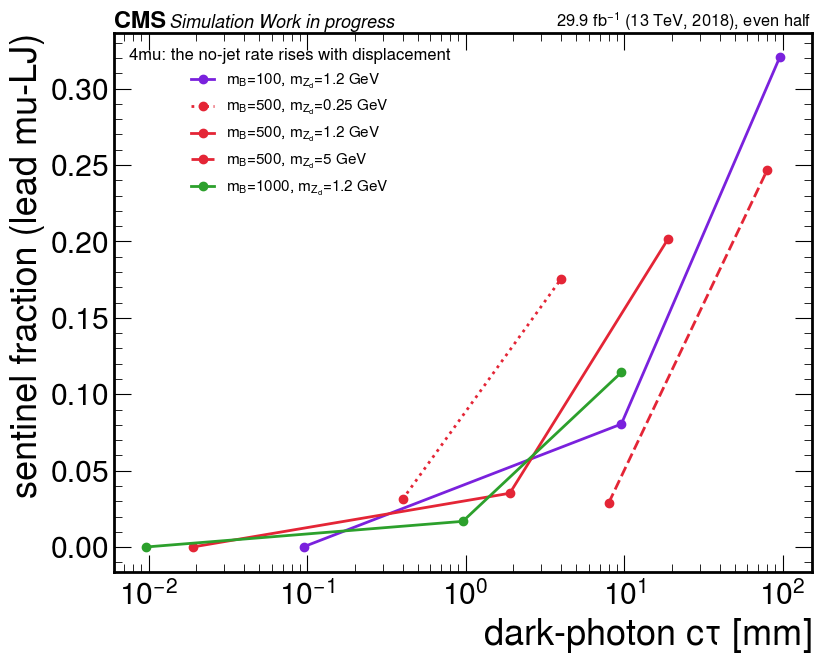

In [6]:
# the same rates as pictures: background per process, signal vs lifetime
for ch, axn, sigs in [("2mu2e", "muiso", ss.SIGNALS_2MU2E),
                      ("4mu", "muiso0", ss.SIGNALS_4MU)]:
    labs = ["total bkg"] + list(ss.PROCESSES)
    vals = [quirk.get(f"{ch}/{l}/{axn}", np.nan) for l in labs]
    fig, axx = plt.subplots(figsize=(8, 5.5))
    axx.bar(labs, np.nan_to_num(vals),
            color=["dimgray"] + [ph.PROC_COLORS[p] for p in ss.PROCESSES])
    axx.set_ylabel("sentinel (no-jet) fraction")
    axx.text(0.03, 0.95, f"{ch}: leading mu-LJ, preselection",
             transform=axx.transAxes, va="top", fontsize=12)
    cms_label(axx); plt.tight_layout(); plt.show()
    pts = {s: quirk[f"{ch}/{s}/{axn}"] for s in sigs
           if np.isfinite(quirk.get(f"{ch}/{s}/{axn}", np.nan))}
    ph.eff_vs_ctau(pts, ylabel="sentinel fraction (lead mu-LJ)",
                   note=f"{ch}: the no-jet rate rises with displacement", ylog=False)

## The scan variables, per process

Stacked background composition of every scan axis at preselection (even half), with
three signal benchmarks overlaid (scaled to be visible). The gray band on the
isolation axes is the sentinel bin (no matched AK4 jet): its background content is
what the incumbent plane cannot constrain. How to read: these are the axes every
plane below is built from; discrimination lives where signal and stack separate.

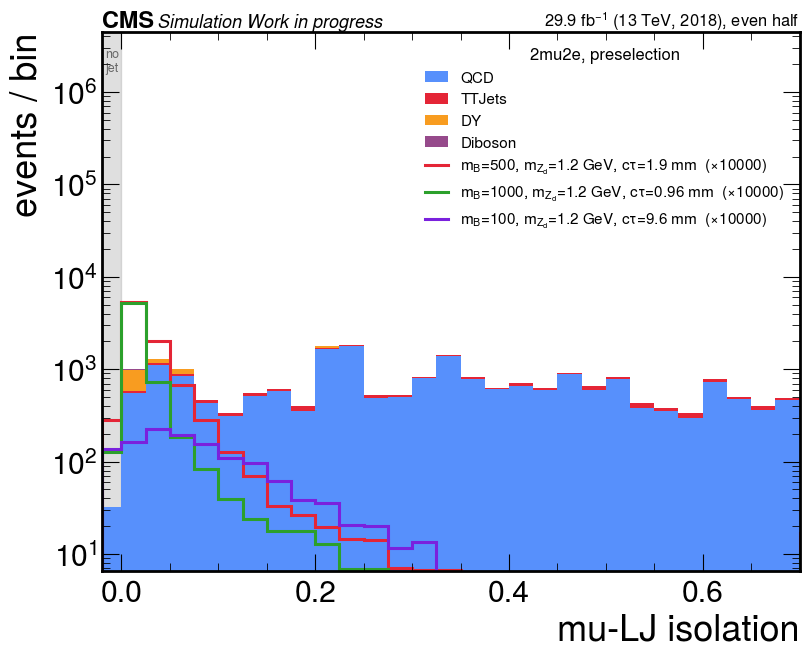

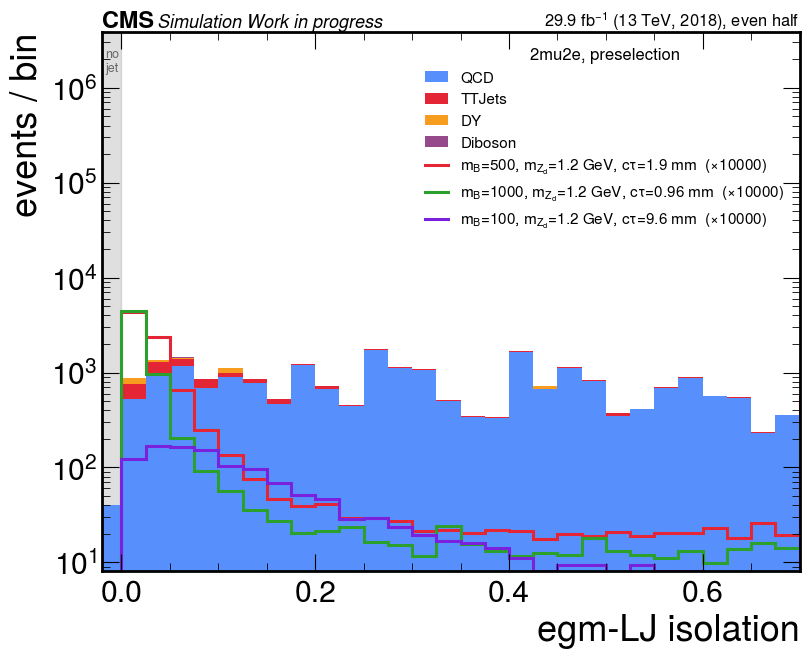

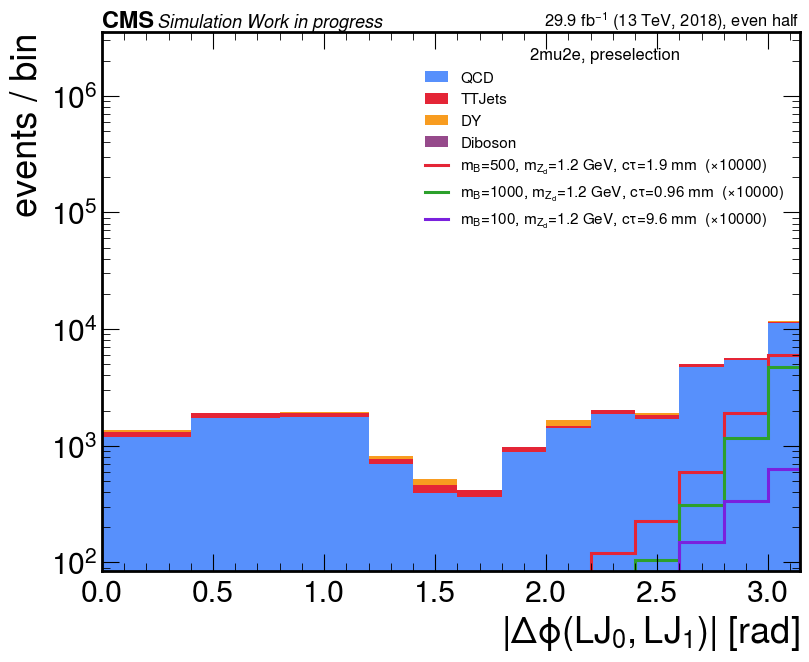

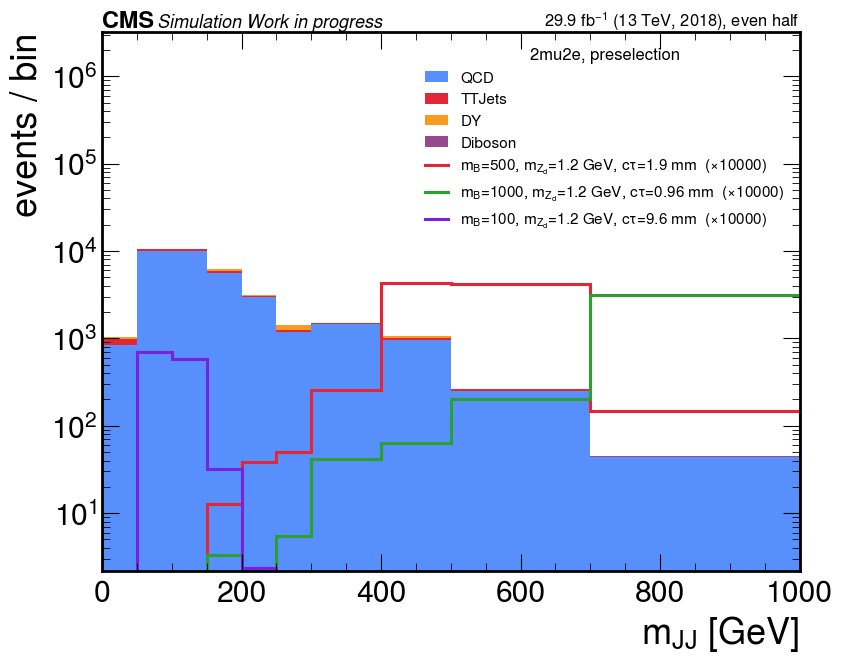

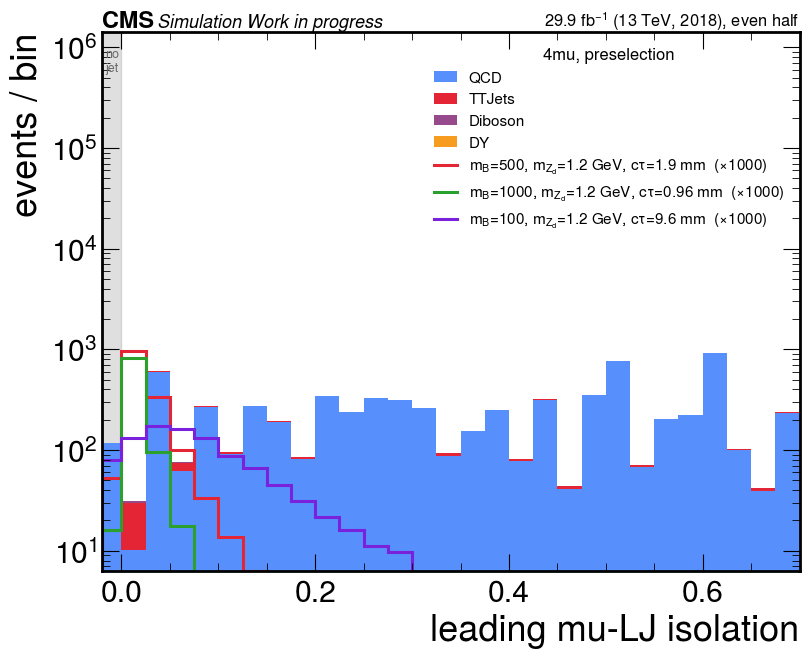

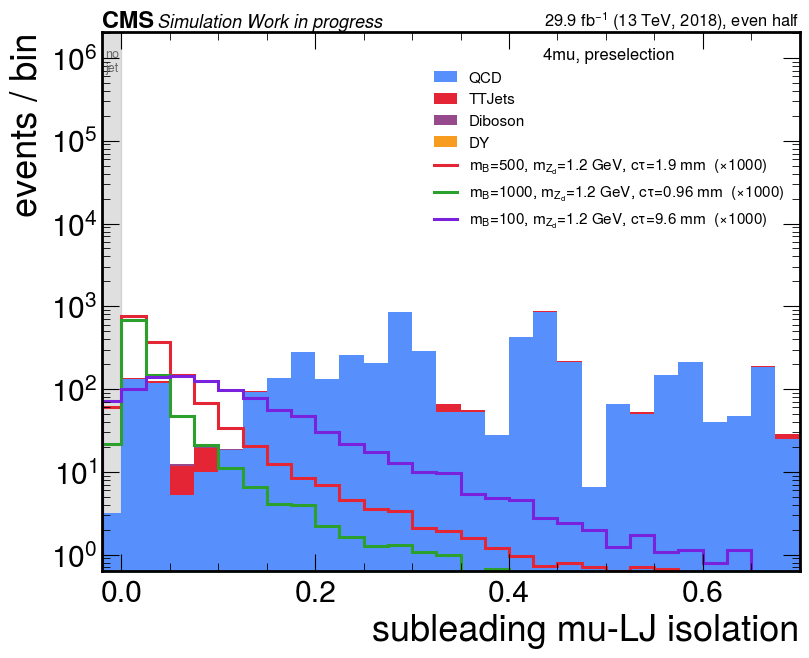

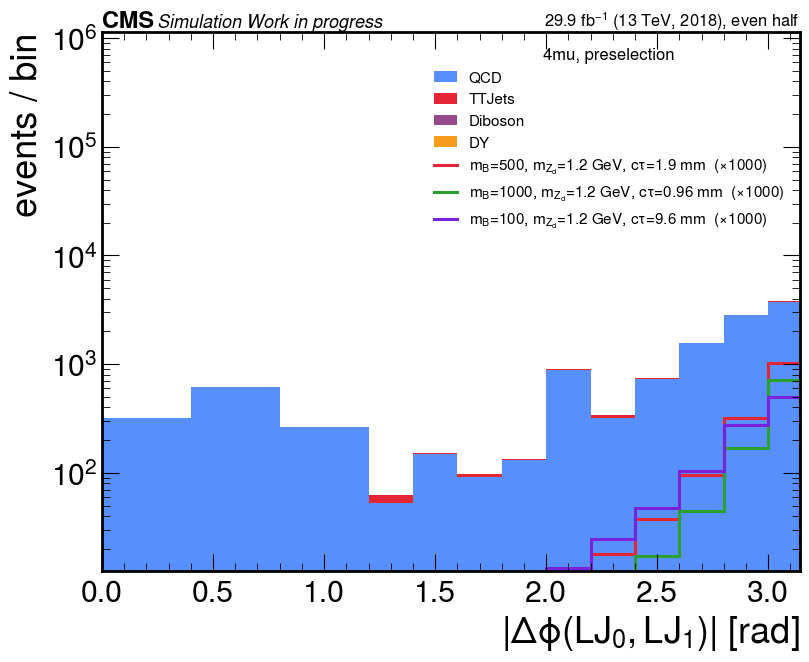

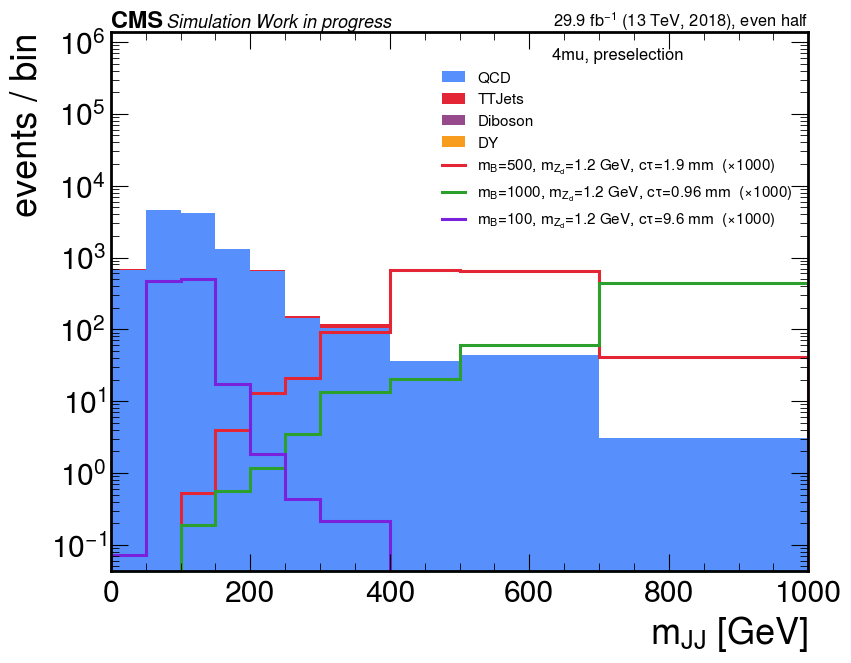

In [7]:
SIG_SHOW = {"2mu2e": ["2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_1000GeV_1p2GeV_0p96mm",
                      "2Mu2E_100GeV_1p2GeV_9p6mm"],
            "4mu": ["4Mu_500GeV_1p2GeV_1p9mm", "4Mu_1000GeV_1p2GeV_0p96mm",
                    "4Mu_100GeV_1p2GeV_9p6mm"]}

def axis1d(hists, hname, ch, axname):
    h = at.get_channel(hists[hname], ss.CHANNELS[ch])
    vals, var, xe, ye = at.project_plane(h, axname, "parity", {})
    return vals[:, 0], xe   # even half

for ch, hname, axes in [("2mu2e", "abcd_scan_2mu2e_iso_iso", ["muiso", "egmiso", "dphi", "mjj"]),
                        ("4mu", "abcd_scan_4mu_iso_iso", ["muiso0", "muiso1", "dphi", "mjj"])]:
    # reduce each shown signal to small 1D arrays first (one hist-dict in memory
    # at a time -- holding several decompressed samples at once OOMs the node)
    sig_axes = {}
    for s in SIG_SHOW[ch]:
        sh = load_sig(s)
        for axname in axes:
            sig_axes[(s, axname)] = axis1d(sh, hname, ch, axname)
        del sh
    for axname in axes:
        procs = []
        for p in ss.PROCESSES:
            v, xe = axis1d(by_process[p], hname, ch, axname)
            procs.append((p, v))
        procs.sort(key=lambda t: -t[1].sum())   # largest at the bottom of the stack
        smax = max(t[1].sum() for t in procs)
        sig_entries = []
        for s in SIG_SHOW[ch]:
            v, sxe = sig_axes[(s, axname)]
            if v.sum() <= 0:
                continue
            scale = 10 ** max(0, int(np.round(np.log10(smax / max(v.sum(), 1e-12) / 10))))
            sig_entries.append((s, v, scale))
        ph.stack1d(procs, xe, xname=axname, signal_entries=sig_entries,
                   note=f"{ch}, preselection")

## The planes, per process

2D distributions of each candidate plane under its SR event cuts (even parity), for
the total background and per process, with the working-point boundaries and the
A/B/C/D regions drawn (A = the signal region; the prediction is A = B·C/D). How to
read them: ABCD needs the shape along x to be independent of y — visually, rows should
look like rescaled copies of each other. The quantitative gate is notebook 02.

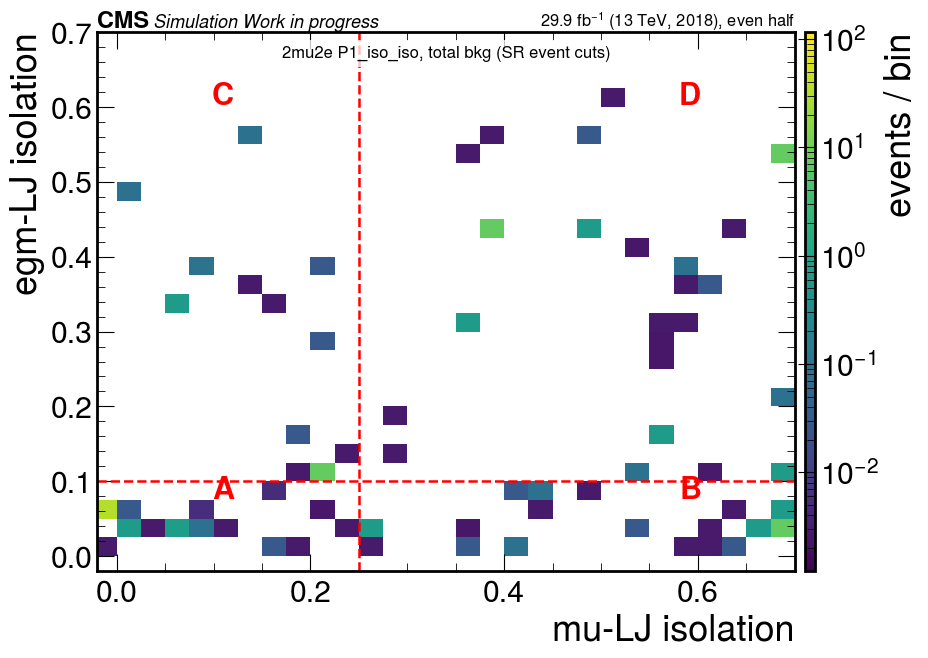

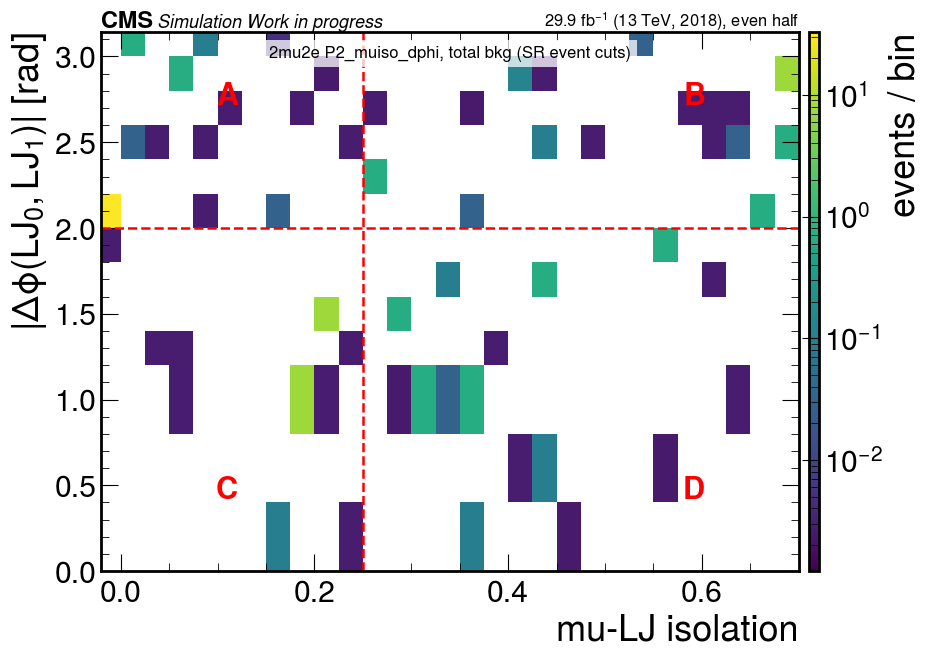

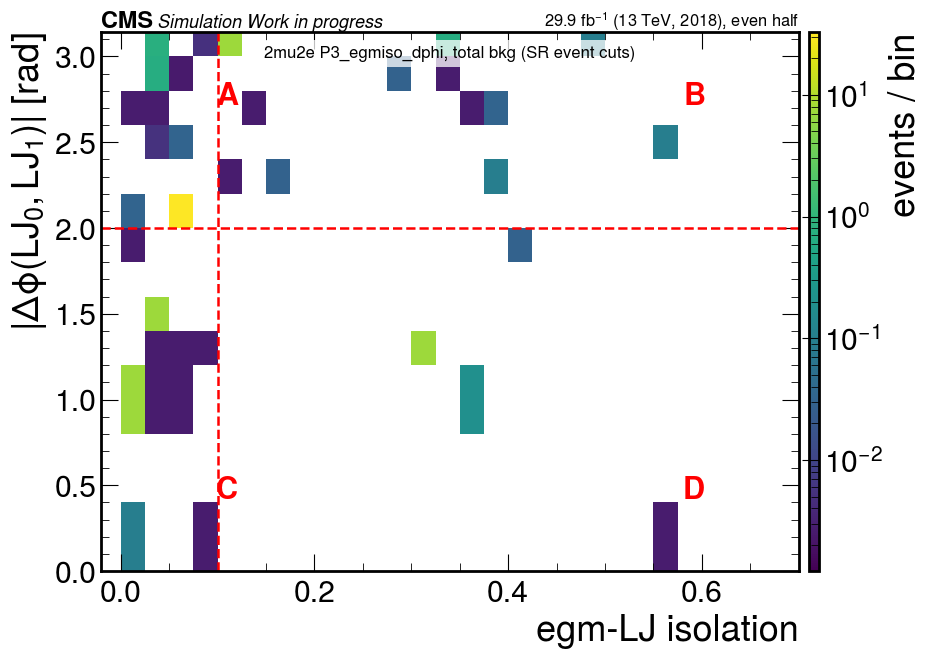

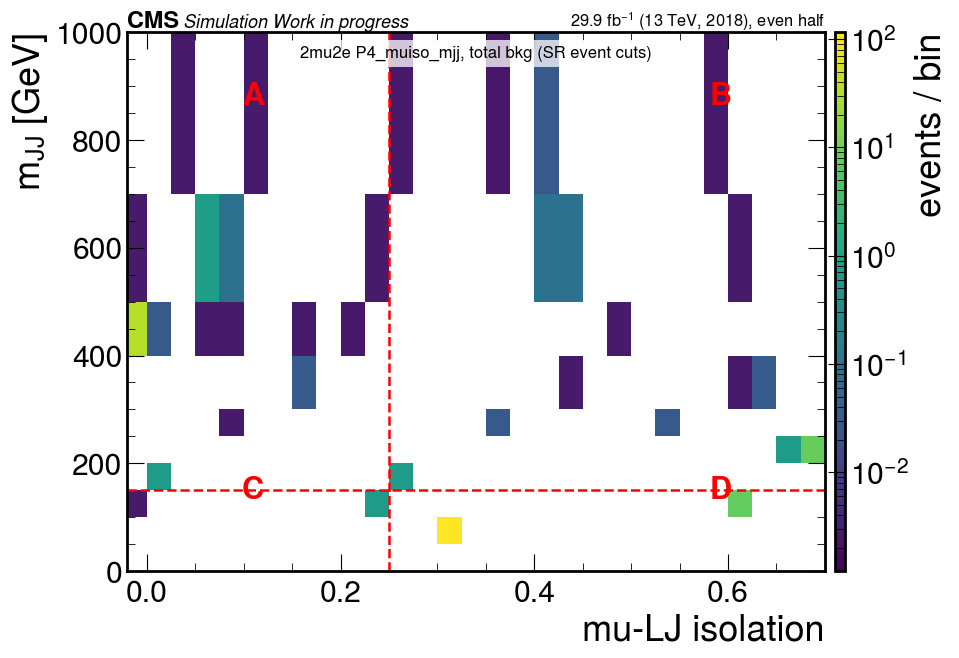

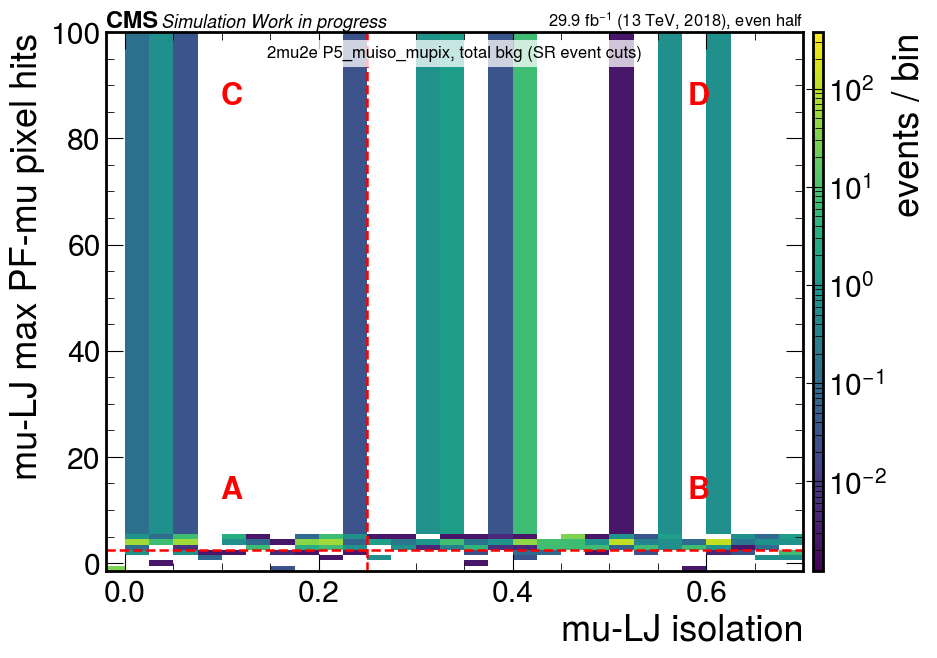

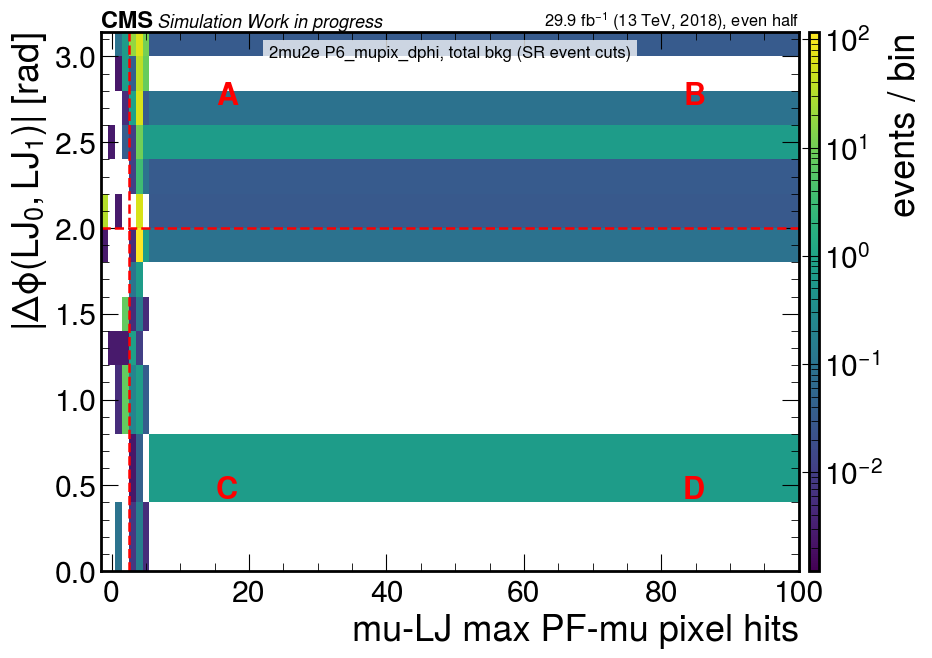

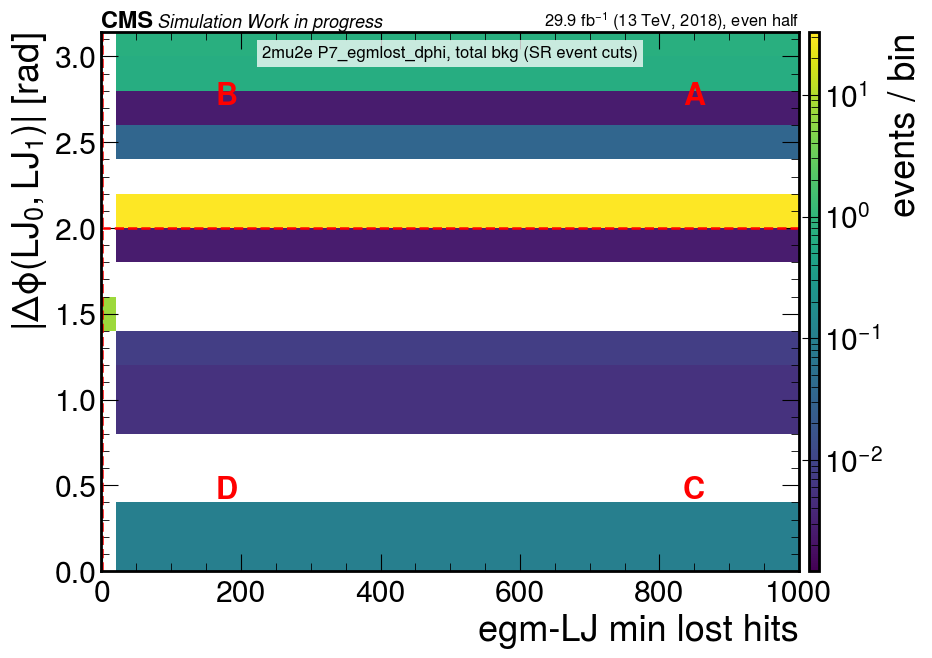

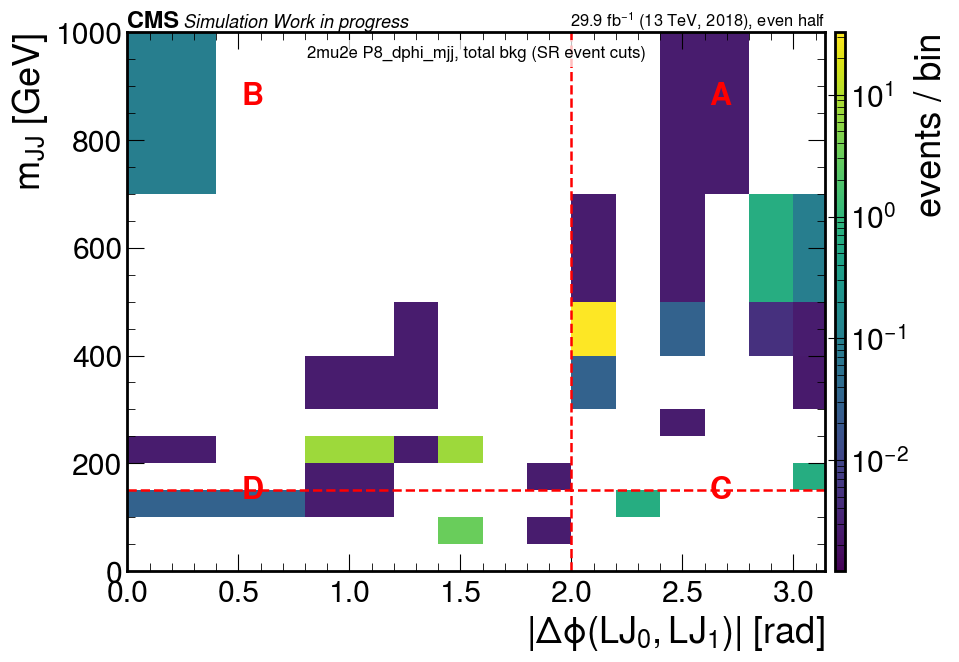

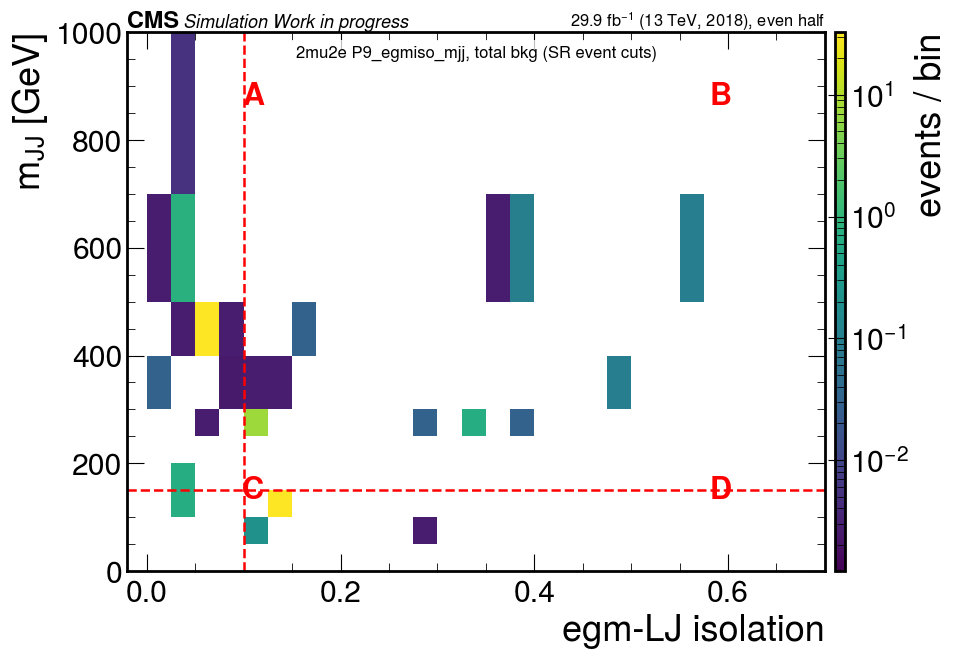

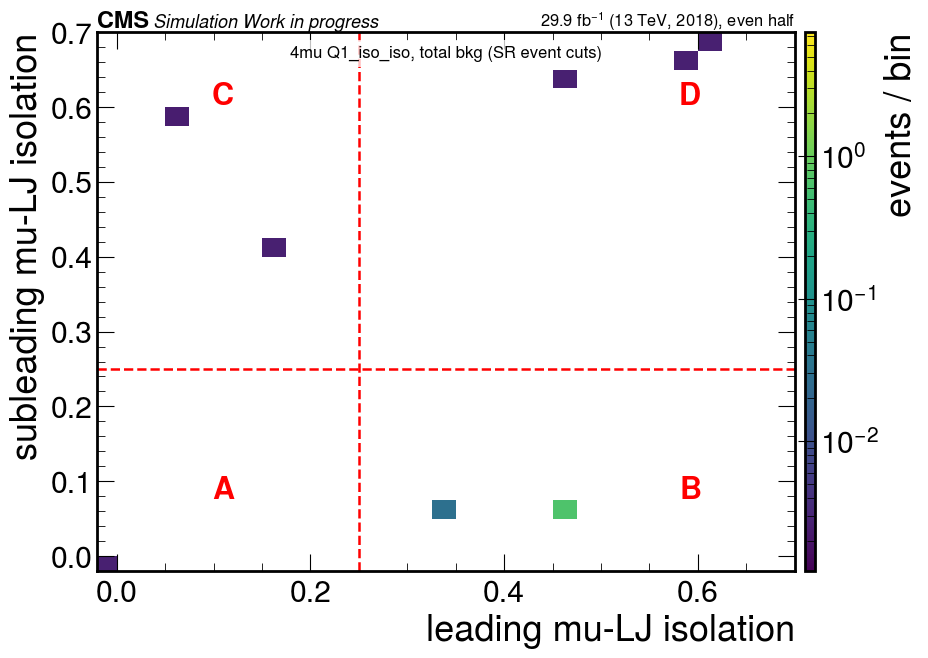

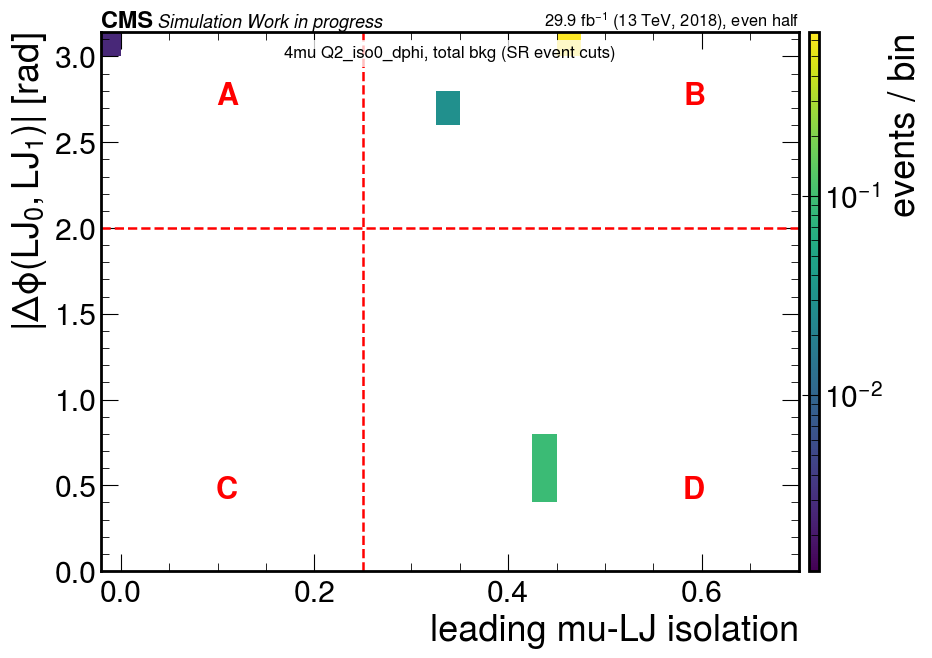

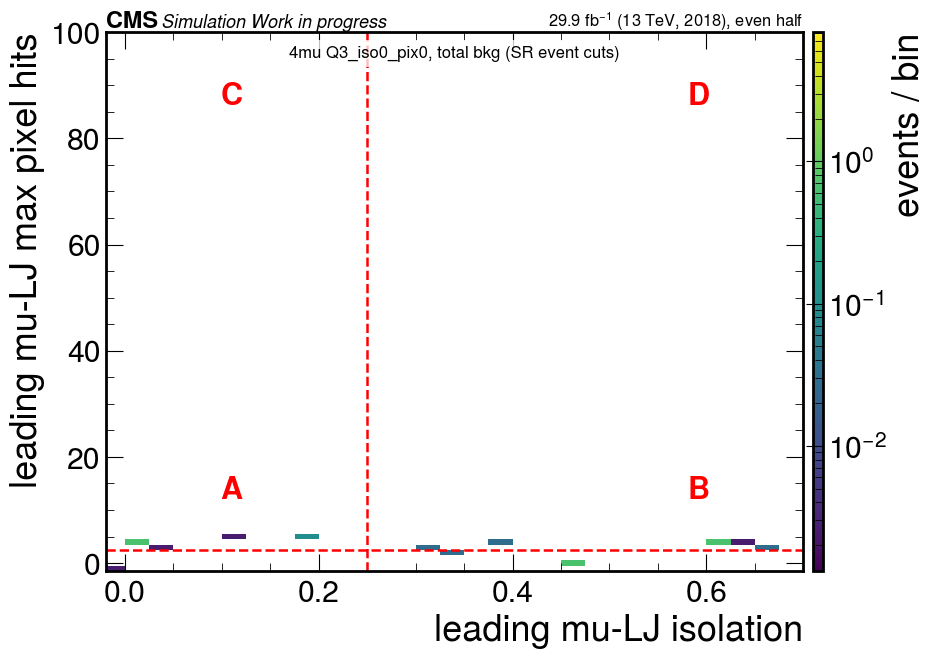

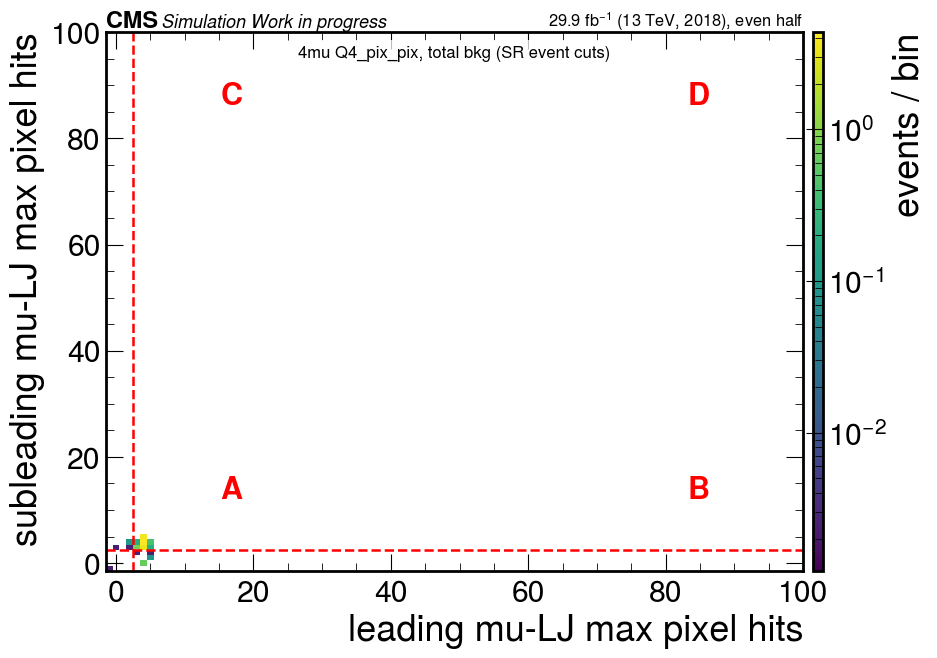

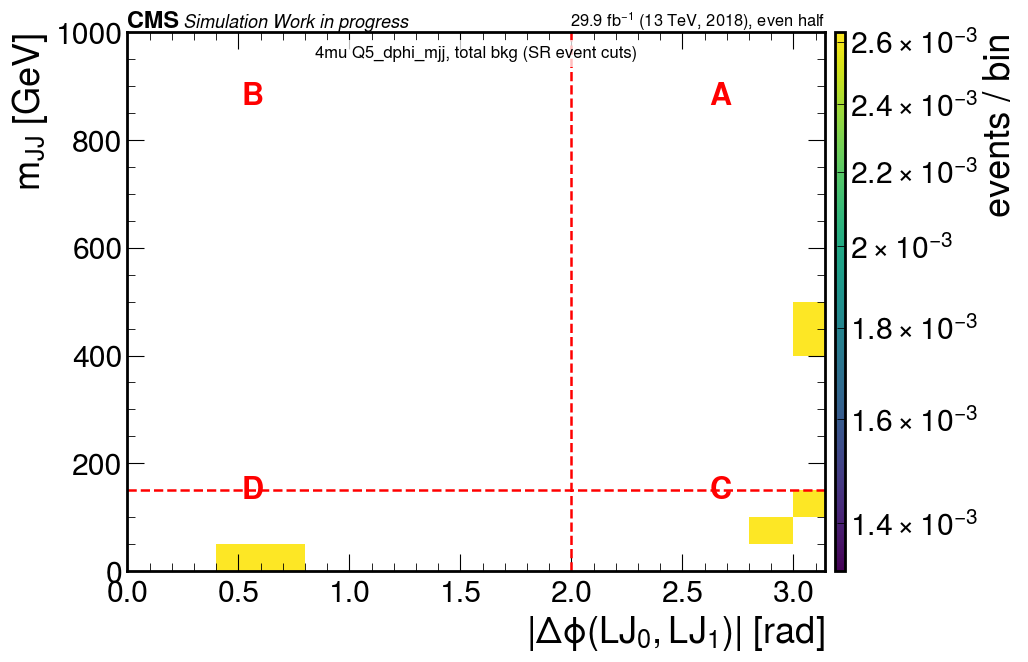

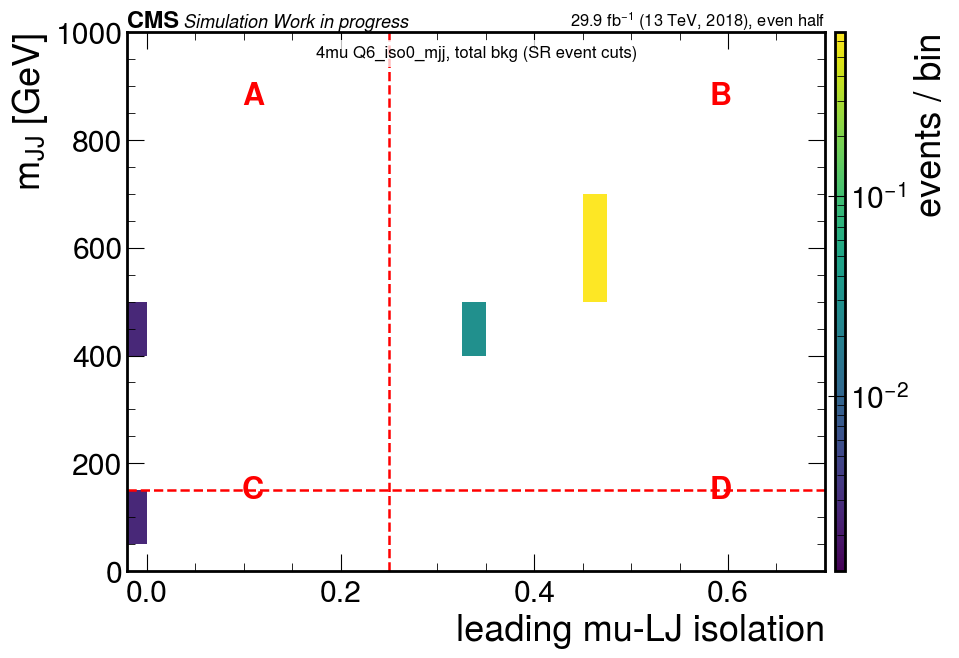

In [8]:
for ch in ss.PLANES:
    for pname, spec in ss.PLANES[ch].items():
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
        ph.plot_plane(vals, xe, ye, f"{ch} {pname}, total bkg (SR event cuts)",
                      xspec=spec["xspec"], yspec=spec["yspec"],
                      xname=spec["x"], yname=spec["y"])

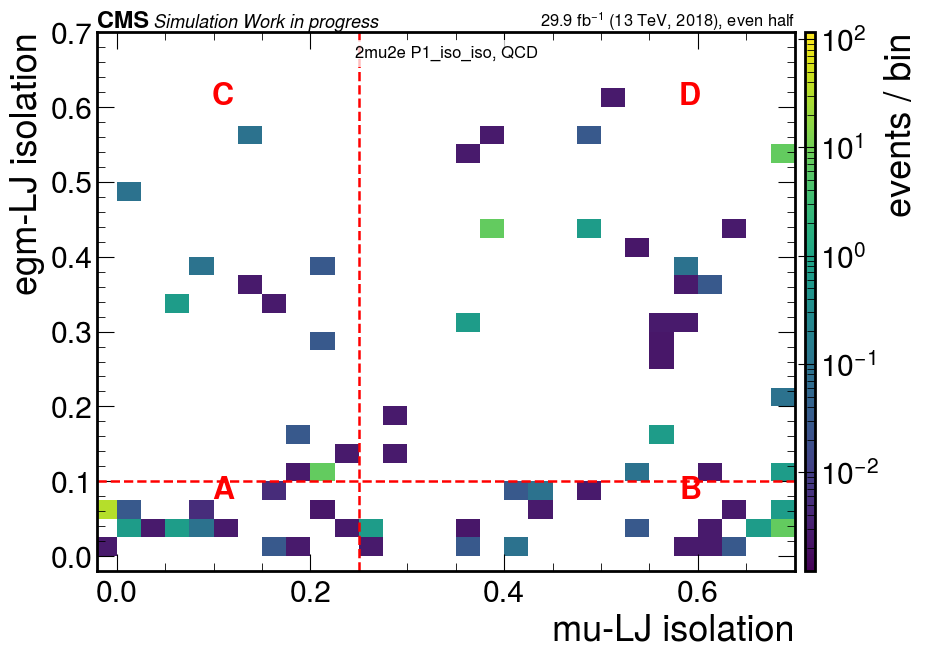

2mu2e P1_iso_iso DY: empty after SR cuts


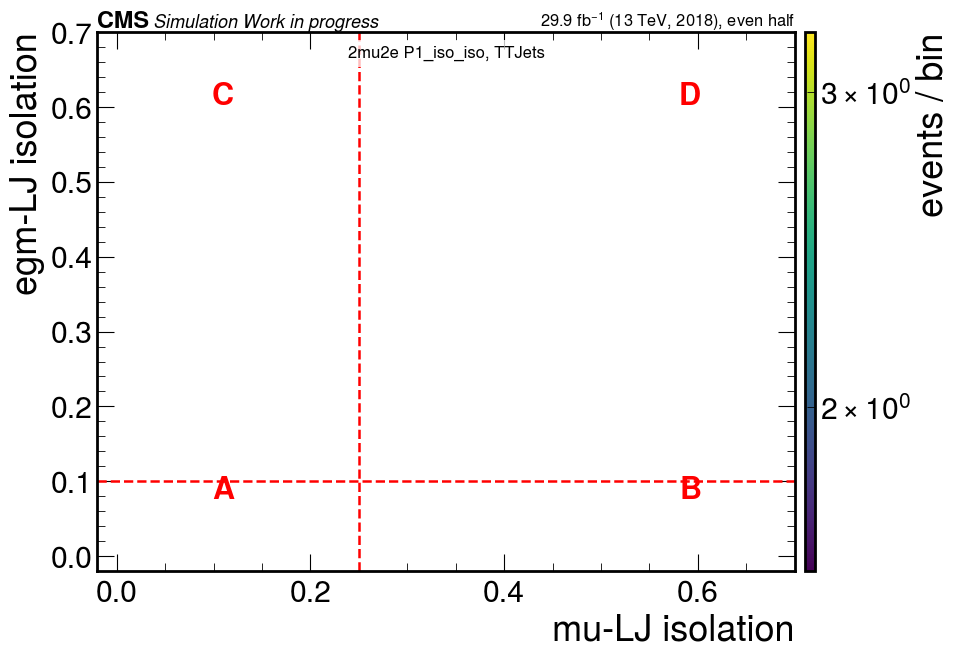

2mu2e P1_iso_iso Diboson: empty after SR cuts


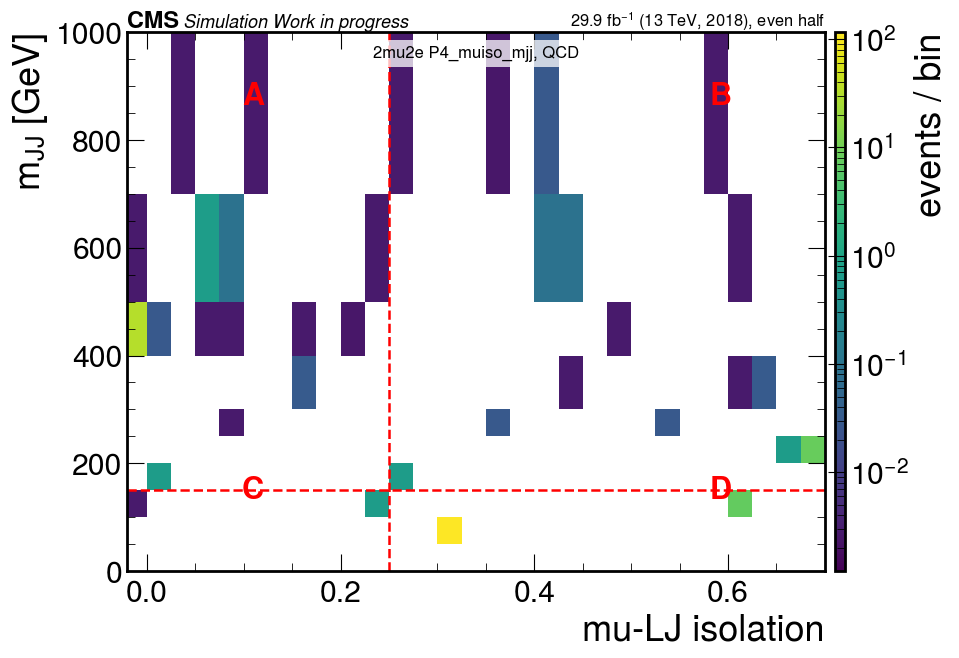

2mu2e P4_muiso_mjj DY: empty after SR cuts
2mu2e P4_muiso_mjj TTJets: empty after SR cuts


2mu2e P4_muiso_mjj Diboson: empty after SR cuts


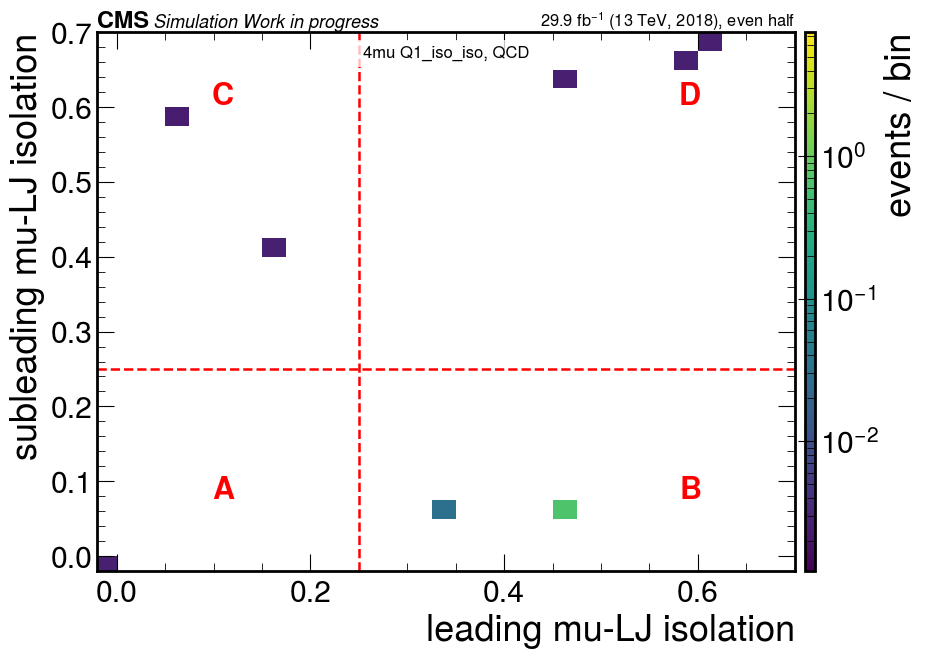

4mu Q1_iso_iso DY: empty after SR cuts


4mu Q1_iso_iso TTJets: empty after SR cuts


4mu Q1_iso_iso Diboson: empty after SR cuts


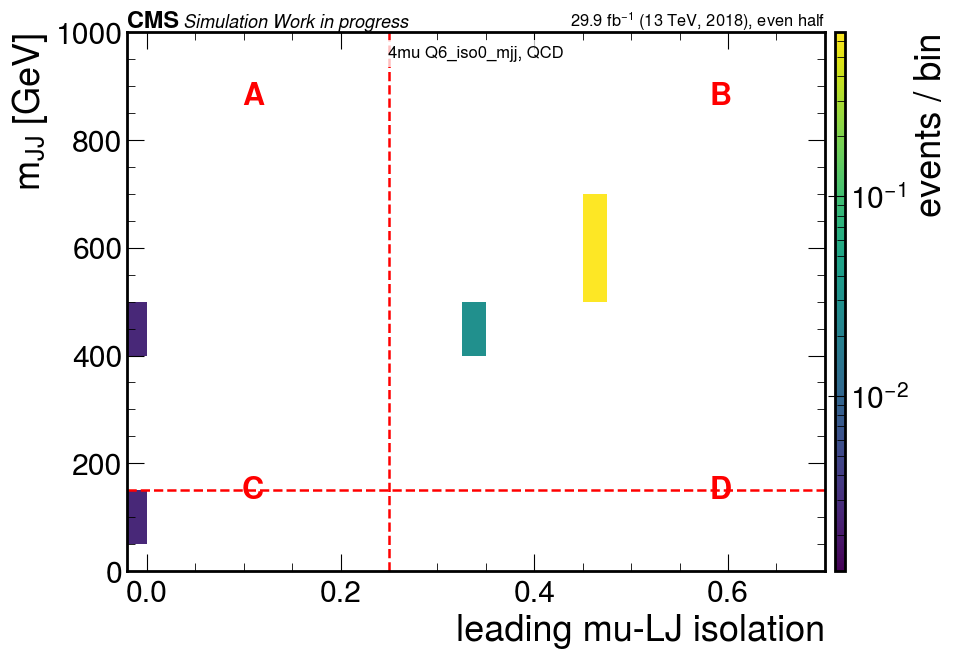

4mu Q6_iso0_mjj DY: empty after SR cuts


4mu Q6_iso0_mjj TTJets: empty after SR cuts


4mu Q6_iso0_mjj Diboson: empty after SR cuts


In [9]:
# per-process versions for the incumbent planes and the mJJ planes
for ch, pname in [("2mu2e", "P1_iso_iso"), ("2mu2e", "P4_muiso_mjj"),
                  ("4mu", "Q1_iso_iso"), ("4mu", "Q6_iso0_mjj")]:
    for p in ss.PROCESSES:
        vals, var, xe, ye = ss.plane_arrays(by_process[p], ch, pname, parity=0)
        if vals.sum() <= 0:
            print(f"{ch} {pname} {p}: empty after SR cuts"); continue
        spec = ss.PLANES[ch][pname]
        ph.plot_plane(vals, xe, ye, f"{ch} {pname}, {p}",
                      xspec=spec["xspec"], yspec=spec["yspec"],
                      xname=spec["x"], yname=spec["y"])

## Weighted correlations (descriptive)

Global weighted Pearson correlation of the two plane variables, per process. Not the
gate (that is the factorization fit in 02), but a first look: |r| well above ~0.1 is
an early warning.

plane                        QCD        DY    TTJets   Diboson     total


2mu2e/P1_iso_iso           0.033       nan       nan       nan     0.032


2mu2e/P2_muiso_dphi        0.177       nan       nan       nan     0.177


2mu2e/P3_egmiso_dphi      -0.224       nan       nan       nan    -0.221


2mu2e/P4_muiso_mjj         0.065       nan       nan       nan     0.065


...

4mu/Q1_iso_iso             0.132       nan       nan       nan     0.132


4mu/Q2_iso0_dphi          -0.820       nan       nan       nan    -0.820


4mu/Q3_iso0_pix0           0.152       nan       nan       nan     0.152
4mu/Q4_pix_pix            -0.310       nan       nan    -0.009     0.048


4mu/Q5_dphi_mjj            0.533       nan       nan       nan     0.533


4mu/Q6_iso0_mjj           -0.984       nan       nan       nan    -0.984


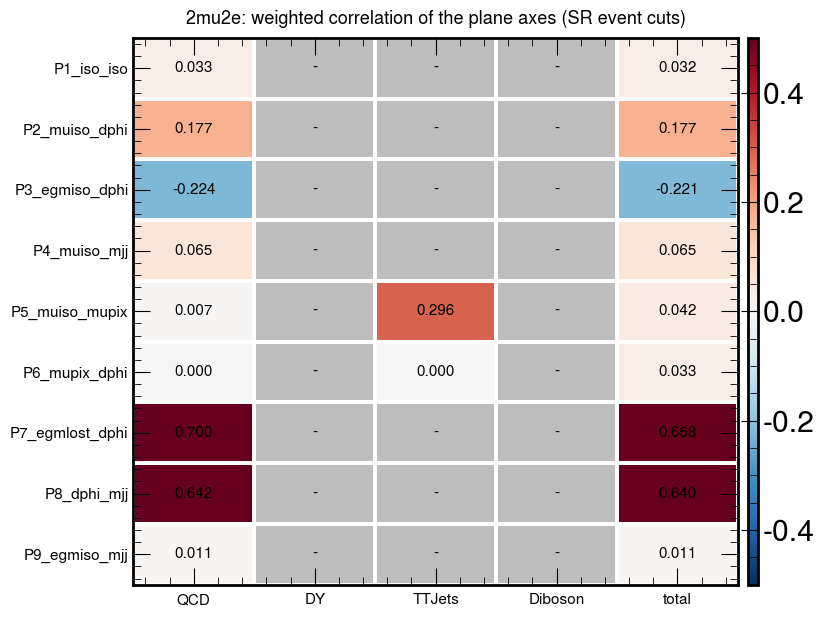

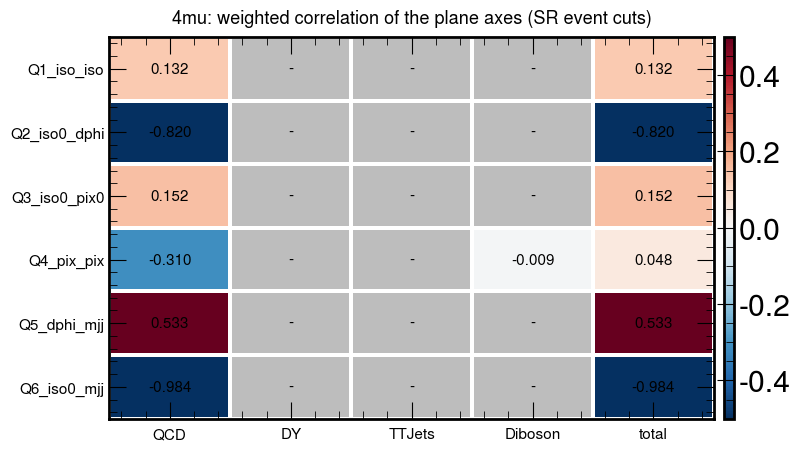

In [10]:
print(f"{'plane':22s} " + " ".join(f"{p:>9s}" for p in ss.PROCESSES) + f" {'total':>9s}")
corr = {}
for ch in ss.PLANES:
    for pname in ss.PLANES[ch]:
        cells = []
        for hset in [by_process[p] for p in ss.PROCESSES] + [total_bkg]:
            vals, var, xe, ye = ss.plane_arrays(hset, ch, pname, parity=0)
            cells.append(at.weighted_correlation(vals, xe, ye))
        corr[f"{ch}/{pname}"] = cells
        print(f"{ch+'/'+pname:22s} " + " ".join(f"{c:9.3f}" for c in cells))
for ch in ss.PLANES:
    rows = [p for p in ss.PLANES[ch]]
    ph.matrix_heatmap([corr[f"{ch}/{p}"] for p in rows], rows,
                      list(ss.PROCESSES) + ["total"],
                      f"{ch}: weighted correlation of the plane axes (SR event cuts)")

## Shape invariance — the ABCD assumption as a picture

For a factorizable plane, the x-axis shape must be independent of y. Each figure:
the normalized x distribution in three y slices (preselection, even half), with the
ratio to the inclusive shape below — flat ratios are what a valid ABCD plane looks
like. The incumbent P1 drifts (the sentinel spike changes share with egm isolation)
and P2 drifts with |Δφ|. P4's jet-matched muiso bulk is stable across mJJ slices,
while the sentinel bin's share does drift between slices — the population notebook
02 examines head-on. The gray band is the MC-stat uncertainty of the inclusive
shape.

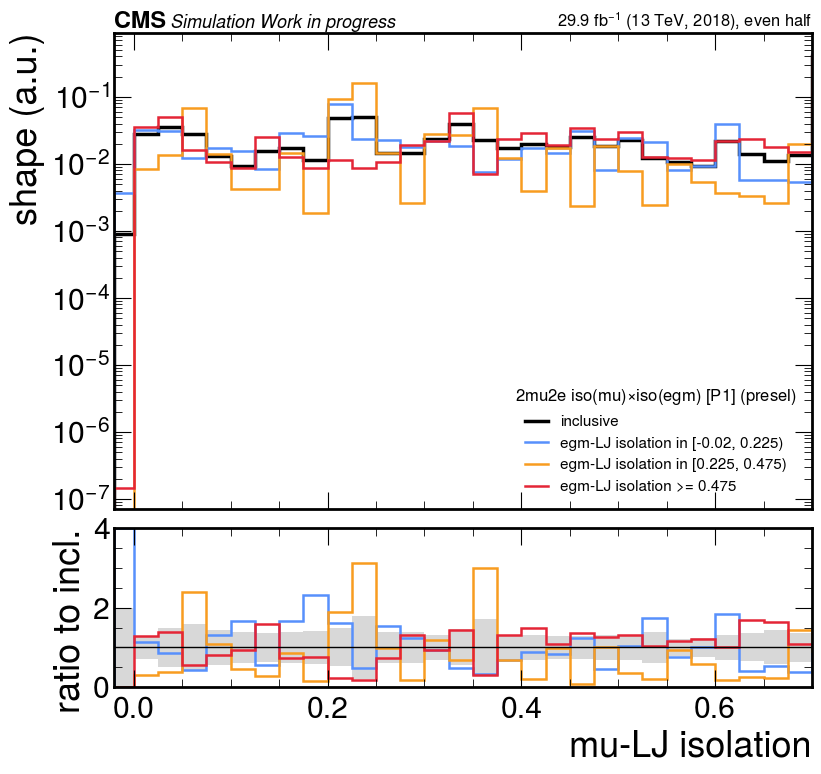

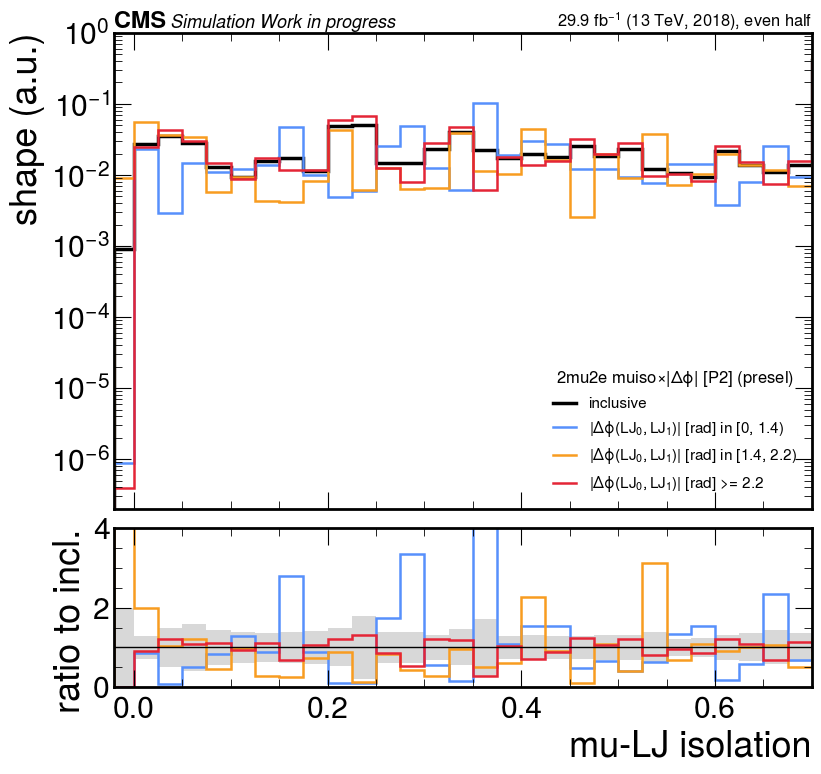

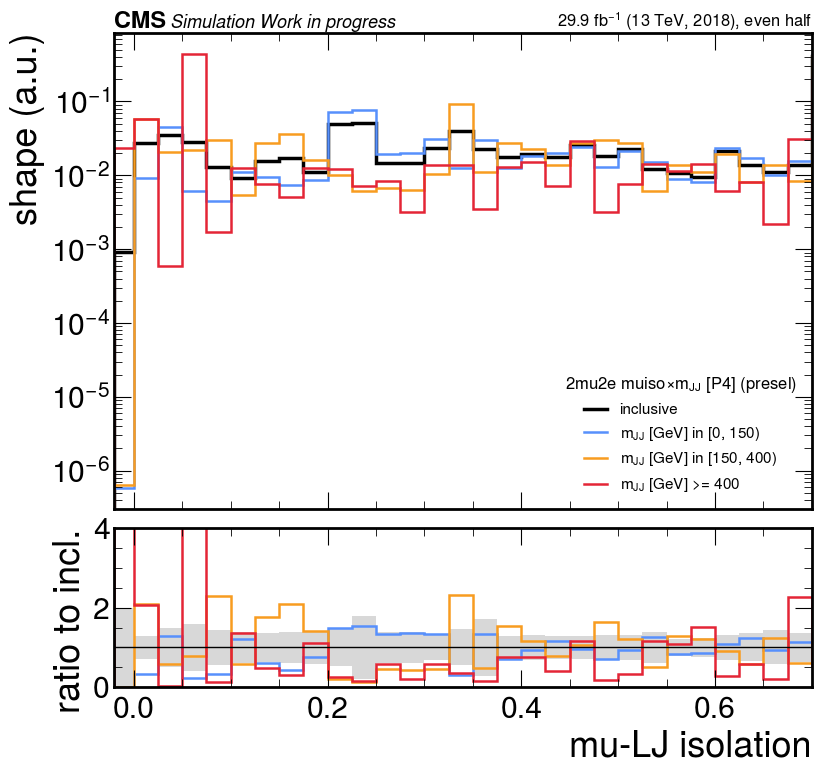

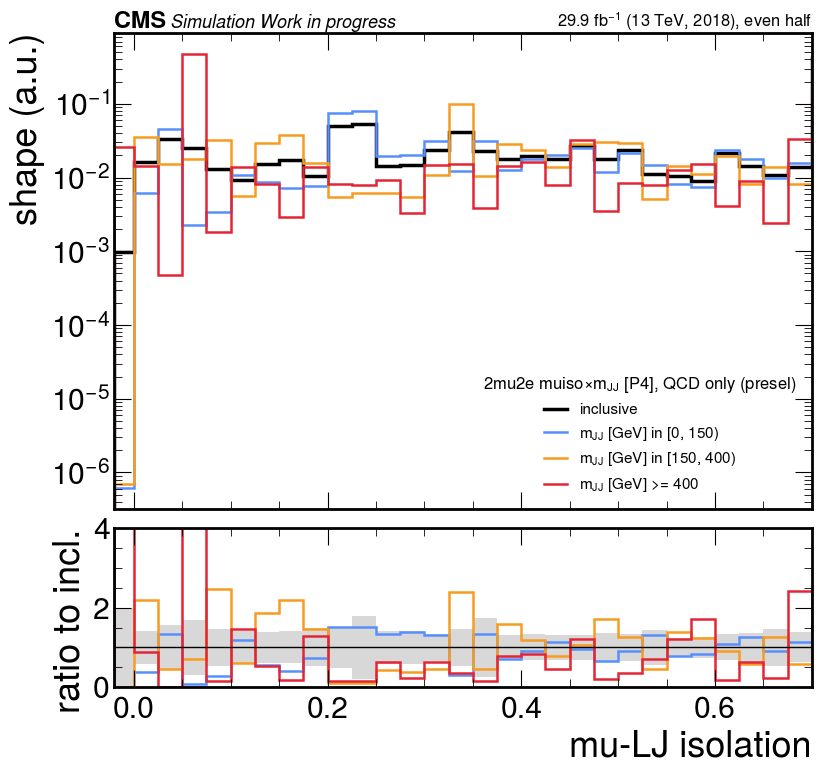

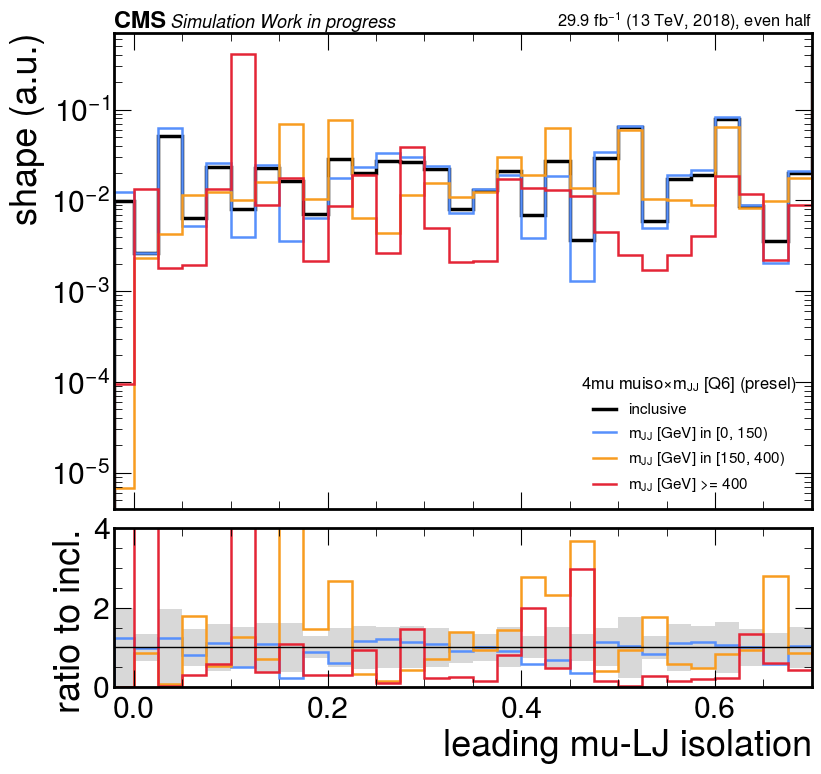

In [11]:
def slice_view(ch, pname, note_extra="", hset=None):
    spec = ss.PLANES[ch][pname]
    vals, var, xe, ye = ss.plane_arrays(hset if hset is not None else total_bkg,
                                        ch, pname, parity=0, cuts_override={})
    n = vals.shape[1]
    blocks = [(0, n // 3), (n // 3, 2 * n // 3), (2 * n // 3, n)]
    svals = [vals[:, a:b].sum(axis=1) for a, b in blocks]
    yl = ph.AXIS_LABELS.get(spec["y"], spec["y"])
    labs = [(f"{yl} in [{ye[a]:g}, {ye[b]:g})" if b < n else f"{yl} >= {ye[a]:g}")
            for a, b in blocks]
    ph.shape_slices(vals.sum(axis=1), xe, svals, labs, xname=spec["x"],
                    note=f"{ch} {ph.nice(pname)}{note_extra} (presel)",
                    var=var.sum(axis=1))

slice_view("2mu2e", "P1_iso_iso")
slice_view("2mu2e", "P2_muiso_dphi")
slice_view("2mu2e", "P4_muiso_mjj")
slice_view("2mu2e", "P4_muiso_mjj", ", QCD only", by_process["QCD"])
slice_view("4mu", "Q6_iso0_mjj")

## Displacement-convention check

The scan axes use PF-muon pixel hits with explicit no-pixel-info (−1) and, on the egm
side, photon-only (999-fill) categories. This section shows where events actually sit,
so the offline displacement choice (N=2 vs N=3, photon-only handling) is made with
open eyes — including the ~63% photon-only fraction of signal 2mu2e events found in
the smoke test.

total bkg                    mudisp[noPix/<=2/==3/>=4]: 0.017/0.058/0.192/0.733   egmdisp[0lost/>=1/photon-only]: 0.537/0.089/0.375


2Mu2E_100GeV_1p2GeV_0p096mm  mudisp[noPix/<=2/==3/>=4]: 0.000/0.035/0.176/0.789   egmdisp[0lost/>=1/photon-only]: 0.963/0.023/0.015


2Mu2E_100GeV_1p2GeV_9p6mm    mudisp[noPix/<=2/==3/>=4]: 0.171/0.659/0.073/0.097   egmdisp[0lost/>=1/photon-only]: 0.107/0.191/0.702


2Mu2E_100GeV_1p2GeV_96p0mm   mudisp[noPix/<=2/==3/>=4]: 0.599/0.343/0.033/0.024   egmdisp[0lost/>=1/photon-only]: 0.033/0.075/0.892


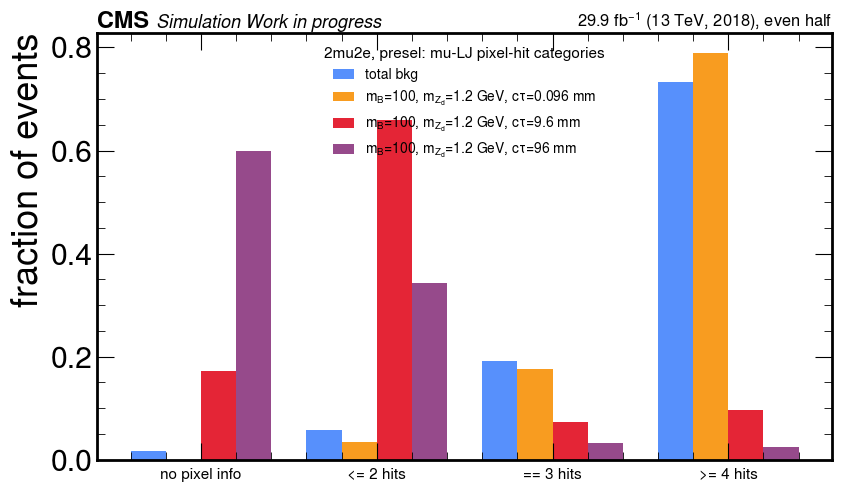

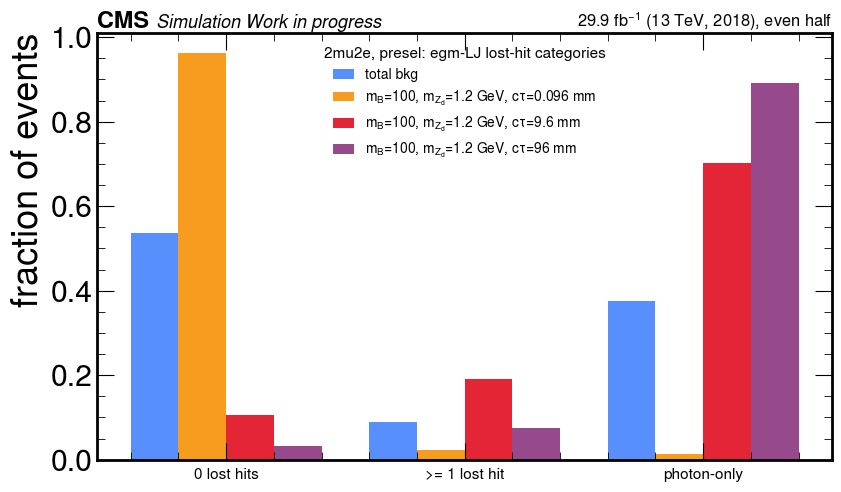

In [12]:
MU_CATS = ["no pixel info", "<= 2 hits", "== 3 hits", ">= 4 hits"]
EGM_CATS = ["0 lost hits", ">= 1 lost hit", "photon-only"]
disp_rows = {}
def _disp_row(label, hists):
    h = at.get_channel(hists["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
    md = at.project_plane(h, "mudisp", "parity", {})[0][:, 0]    # even half
    ed = at.project_plane(h, "egmdisp", "parity", {})[0][:, 0]
    mt, et = md.sum(), ed.sum()
    if mt <= 0: return
    disp_rows[label] = ([md[i] / mt for i in range(4)],
                        [ed[i] / et for i in range(3)])
    print(f"{label:28s} mudisp[noPix/<=2/==3/>=4]: "
          + "/".join(f"{md[i]/mt:.3f}" for i in range(4))
          + f"   egmdisp[0lost/>=1/photon-only]: "
          + "/".join(f"{ed[i]/et:.3f}" for i in range(3)))
_disp_row("total bkg", total_bkg)
for s in ss.SIGNALS_2MU2E[:3]:
    hs = load_sig(s)
    _disp_row(s, hs)
    del hs
for cats, idx, ttl in [(MU_CATS, 0, "mu-LJ pixel-hit categories"),
                       (EGM_CATS, 1, "egm-LJ lost-hit categories")]:
    fig, axx = plt.subplots(figsize=(9, 5.5))
    x = np.arange(len(cats)); nb = len(disp_rows); w = 0.8 / nb
    for k, (lab, row) in enumerate(disp_rows.items()):
        short = ph.sig_label(lab) if "_" in lab else lab
        axx.bar(x + (k - (nb - 1) / 2) * w, row[idx], w, label=short)
    axx.set_xticks(x, cats, fontsize=11)
    axx.set_ylabel("fraction of events")
    axx.legend(title=f"2mu2e, presel: {ttl}", fontsize=10, title_fontsize=11, framealpha=0.85)
    cms_label(axx); plt.tight_layout(); plt.show()

## mJJ sculpting inputs

Normalized leading mu-LJ isolation shapes in mJJ slices (total background). How to
read it: if the shapes drift with mJJ, an mJJ cut sculpts the iso axes — the effect
Samuel's study saw as closure degrading at low mJJ. Notebook 02 quantifies it per
process; this is the picture.

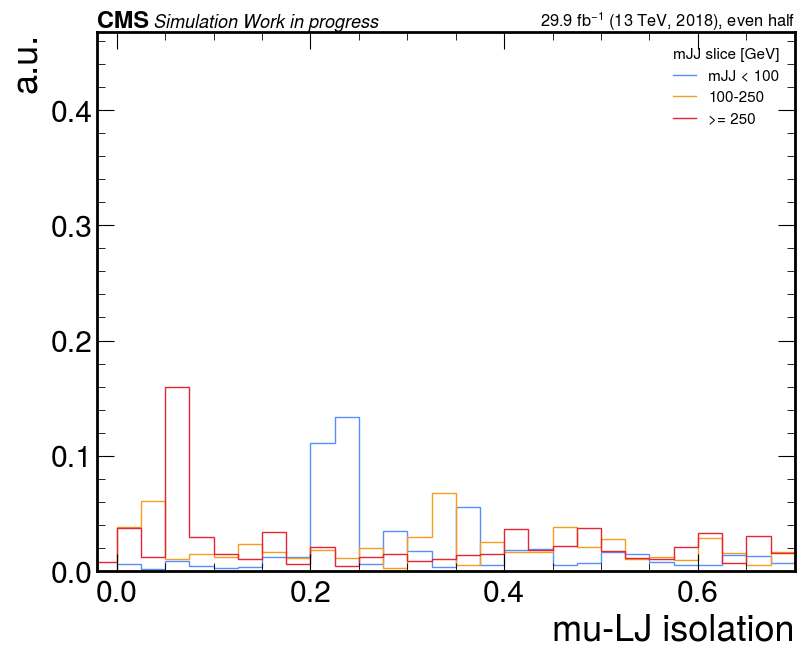

In [13]:
h = at.get_channel(total_bkg["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
fig, ax = plt.subplots()
for lo, hi, lab in [(0, 100, "mJJ < 100"), (100, 250, "100-250"), (250, 14000, ">= 250")]:
    vals, var, xe, ye = at.project_plane(h, "muiso", "egmiso",
        {"mjj": ("window", float(lo), float(hi)), "parity": ("bin", 0)})
    proj = vals.sum(axis=1)
    if proj.sum() > 0:
        ax.stairs(proj / proj.sum(), xe, label=lab)
ax.set_xlabel("mu-LJ isolation"); ax.set_ylabel("a.u."); ax.set_xlim(-0.02, 0.7)
ax.legend(title="mJJ slice [GeV]", fontsize=11, title_fontsize=11); cms_label(ax)
plt.show()

## mJJ spectra, the 150 GeV boundary, and which masses matter

Two ingredients decide how mJJ is used. (1) The two-LJ invariant mass reconstructs
the bound state: each signal peaks at its m_B, so 150 GeV cleanly separates the
m_B ≥ 500 grid from the background bulk, while m_B = 100 sits *below* the boundary.
(2) The production cross section at the dijet-constrained mediator benchmark
(m_A = 750 GeV): σ falls below 0.05 fb for m_B ≤ 200 — fewer than 3 events produced
in the full 2018 dataset before any selection — so the light mass points are kept
as illustrations, not search targets. Two caveats belong next to that statement:
the suppression is distance from the s-channel resonance, so it is a statement
about this benchmark (m_A = 750 GeV, tan β = 1, α_D = 0.2), not about all allowed
parameter space; and adopting a single high-mass region forecloses m_B ≤ 200
limits — a scope decision that needs collaboration sign-off (the two-region
machinery is retained as the fallback). Under that scope: **one high-mass search
region (mJJ ≥ 150 GeV), and the low-mJJ side becomes a validation region that is
signal-free for every m_B ≥ 500 point** (leakage quantified in notebook 03).

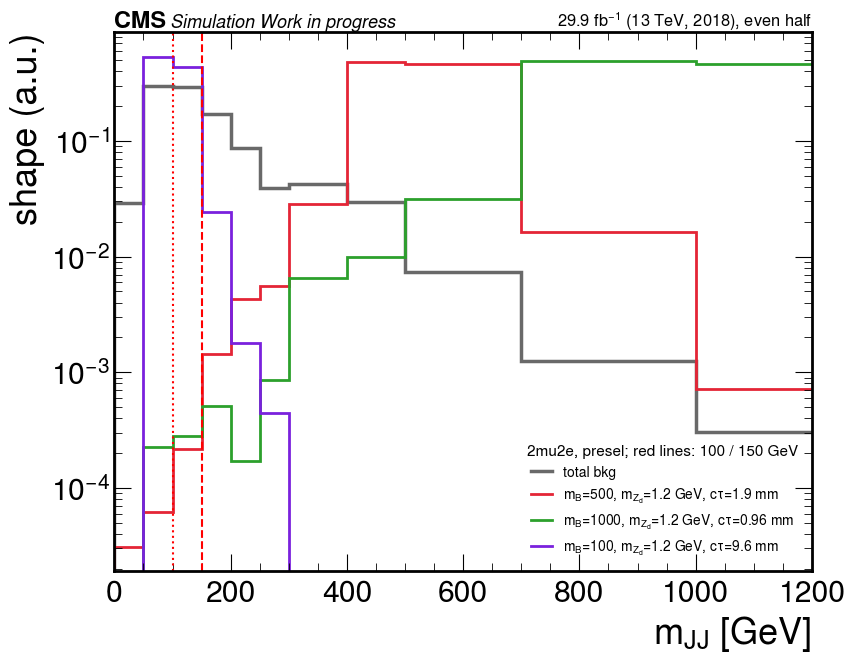

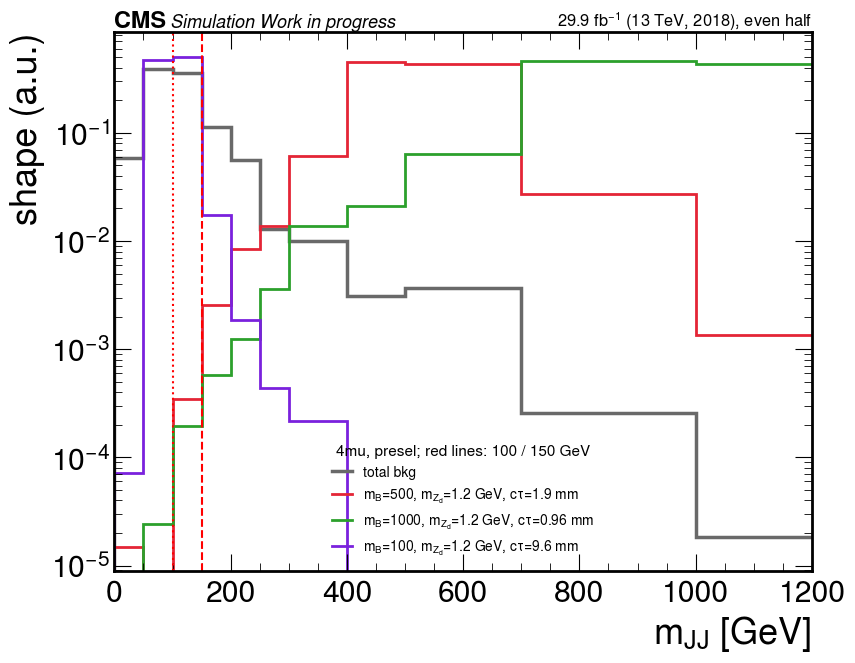

In [14]:
def mjj_shape(hists, ch):
    hname = "abcd_scan_2mu2e_iso_iso" if ch == "2mu2e" else "abcd_scan_4mu_iso_iso"
    h = at.get_channel(hists[hname], ss.CHANNELS[ch])
    other = [a.name for a in h.axes if a.name not in ("mjj", "parity")]
    vals, var, xe, ye = at.project_plane(h, "mjj", "parity", {axo: "sum" for axo in other})
    return vals[:, 0], xe

for ch in ("2mu2e", "4mu"):
    fig, axx = plt.subplots()
    v, xe = mjj_shape(total_bkg, ch)
    axx.stairs(v / v.sum(), xe, color="dimgray", lw=2.5, label="total bkg")
    for s in SIG_SHOW[ch]:
        v, xe = mjj_shape(load_sig(s), ch)
        if v.sum() > 0:
            axx.stairs(v / v.sum(), xe, lw=2,
                       color=ph.MASS_COLORS[ph.parse_sig(s)[0]], label=ph.sig_label(s))
    for b, style in [(100, ":"), (150, "--")]:
        axx.axvline(b, color="red", ls=style, lw=1.5)
    axx.set_xlim(0, 1200); axx.set_yscale("log")
    axx.set_xlabel(ph.AXIS_LABELS["mjj"]); axx.set_ylabel("shape (a.u.)")
    axx.legend(title=f"{ch}, presel; red lines: 100 / 150 GeV", fontsize=10,
               title_fontsize=11, framealpha=0.85)
    cms_label(axx); plt.show()

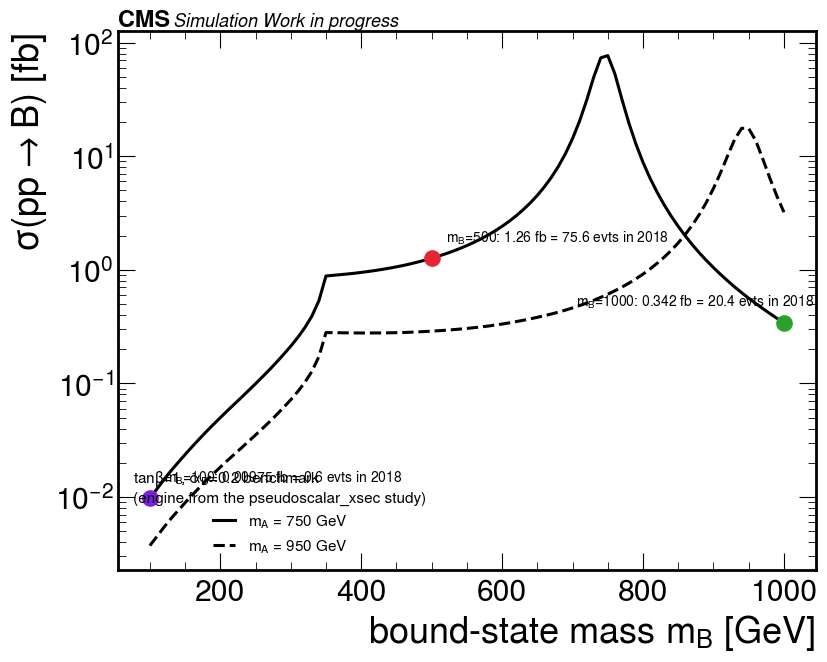

In [15]:
# production cross section vs bound-state mass; the m_B suppression at low
# mass is distance from the s-channel resonance, so it is shown for two mediator
# masses -- the demotion of the light points is BENCHMARK-DEPENDENT (see the md).
sys.path.insert(0, os.path.join(os.getcwd(), "..", "pseudoscalar_xsec"))
import pseudoscalar_xsec as px
from mstwpdf import MSTWPDF
pdf = MSTWPDF(os.path.join(os.getcwd(), "..", "pseudoscalar_xsec", "mstw2008nnlo.00.dat"))
mB = np.arange(100, 1001, 10.0)
fig, axx = plt.subplots()
tot750 = None
for mA, style in [(750, "k-"), (950, "k--")]:
    _, _, tot = px.scan_mB(pdf, mB, mA=mA, tanb=1, alphaD=0.2, yq=1, ychi=1)
    axx.plot(mB, tot, style, lw=2.2, label=f"$m_A$ = {mA} GeV")
    if mA == 750:
        tot750 = tot
for m, dx in [(100, 10), (500, 10), (1000, -150)]:
    sxs = float(np.interp(m, mB, tot750))
    axx.plot([m], [sxs], "o", ms=11, color=ph.MASS_COLORS[m])
    axx.annotate(f"$m_B$={m}: {sxs:.3g} fb = {sxs*59.83:.1f} evts in 2018",
                 (m, sxs), textcoords="offset points", xytext=(dx, 12), fontsize=10)
axx.set_yscale("log")
axx.set_xlabel(r"bound-state mass $m_B$ [GeV]")
axx.set_ylabel(r"$\sigma(pp \to B)$ [fb]")
axx.legend(title="tan$\\beta$=1, $\\alpha_D$=0.2 benchmark\n"
           "(engine from the pseudoscalar_xsec study)",
           fontsize=11, title_fontsize=11, framealpha=0.85, loc="lower left")
cms_label(axx, rlabel="")
plt.show()

## Findings

- Normalization factors are all in range (the setup-cell tripwire enforces it);
  DY-M50 is excluded and count-bounded; TTJets stays at 471.7 pb with the NNLO move
  quantified above as a small composition effect.
- The sentinel (no matched AK4 jet) population is negligible for egm-LJs and small
  for background mu-LJs at preselection, but rises steeply with signal displacement
  (up to ~36% of mu-LJs at the longest lifetimes) — and notebook 02 shows it is the
  dominant surviving population in the naive tight signal region.
- The shape-invariance panels preview the notebook-02 fit verdicts: P1 (sentinels
  included) and P2 drift visibly; P4's jet-matched muiso bulk is stable across mJJ
  slices (the sentinel bin's share drifts — quantified in notebook 02).
- mJJ reconstructs the bound-state mass. At the m_A = 750 GeV benchmark, m_B ≤ 200
  is produced at < 0.05 fb (< 3 events in all of 2018), so the search uses a single
  high-mass region (mJJ ≥ 150 GeV) and the low-mJJ side serves as a signal-free
  validation region.